## Fintech & Risk Assessment: Predicting Loan Default

### DATA LOADING

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
dfrain = pd.read_csv('application_train.csv', low_memory=False)
dfrain.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
target = dfrain['TARGET']
train_id = dfrain['SK_ID_CURR']
dfrain = dfrain.drop(columns=['TARGET'])

In [4]:
print(target.value_counts(normalize=True)) 

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


###  EXPLORATORY DATA ANALYSIS 

In [5]:
dfrain.describe()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.977752,0.755746,0.044595,0.07807

When I ran .describe() on the training set, two data quality issues stood out right away.

First, the count row is inconsistent across variables. Some columns have the full ~307k observations, but others are way lower. For example, OWN_CAR_AGE only has around 104k non-null values, and EXT_SOURCE_1 is missing more than half of its entries. That is not something you can ignore. Those gaps will either need to be imputed carefully or the variables removed, depending on how important they are to the model.

Second, DAYS_EMPLOYED clearly has a structural issue. The mean is 63,815 days and the maximum is 365,243 days, which is roughly 1,000 years of employment. That is not realistic. This is almost definitely a sentinel value being used to represent missing data. If that is not handled properly before modeling, it will completely distort feature importance and predictions.

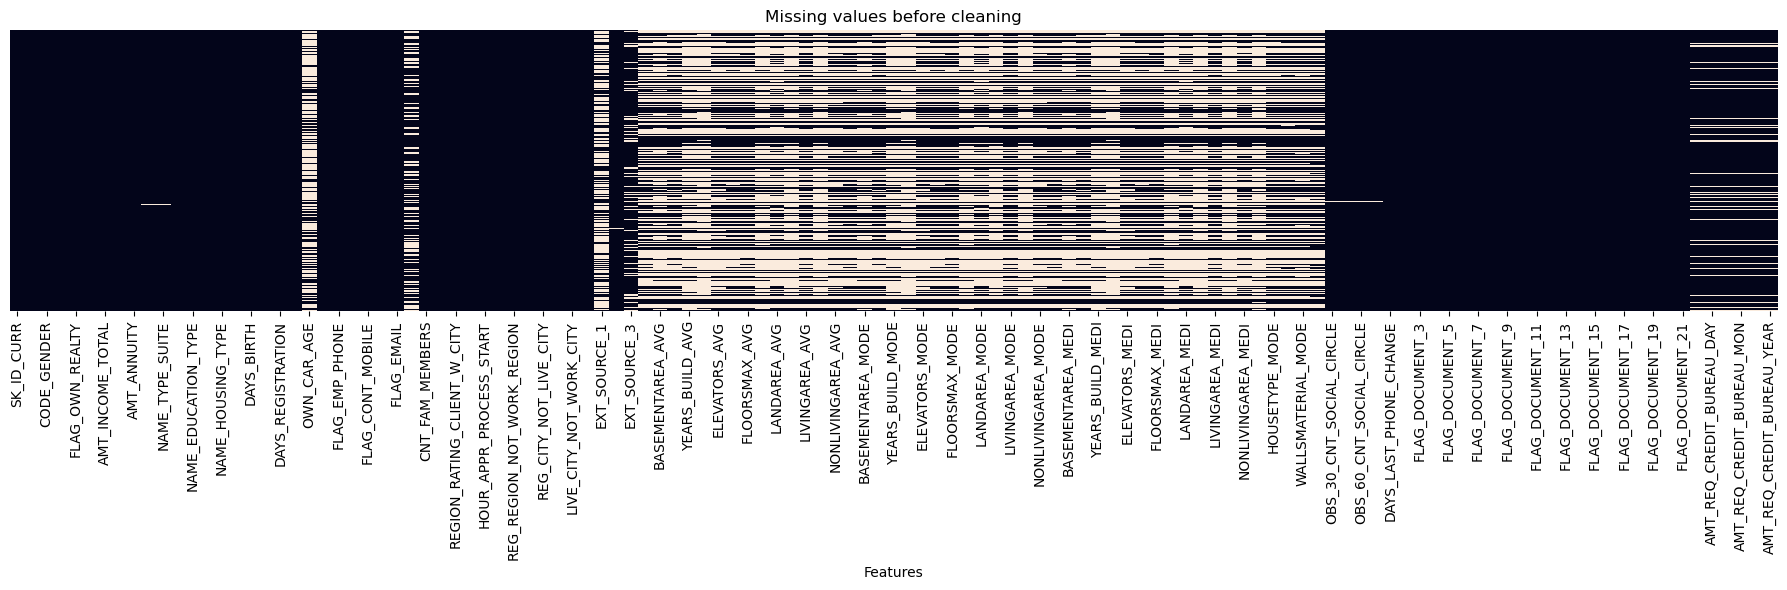

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_train = dfrain.sample(5000, random_state=42)

plt.figure(figsize=(18, 6))
sns.heatmap(
    sample_train.isnull(),
    yticklabels=False,
    cbar=False
)

plt.title("Missing values before cleaning")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

The missing values heatmap shows dense white blocks across variables like years_build_avg, livingarea_avg, housetype_mode, and other housing characteristics, with many missing a good chunk of their data. That is a large portion of the dataset and cannot just be ignored.

These variables describe the physical details of the applicant’s residence, not employment or income. It makes sense that they are sparse since many applicants likely do not have detailed property records available, or that information simply was not collected. With that much missingness, keeping all of them without a clear plan would probably introduce more noise than value.

In [7]:
missing_train = (dfrain.isnull().sum().sort_values(ascending=False).head(20))

missing_train = missing_train[missing_train > 0]

print("Top 20 columns with missing values:")
print(missing_train)

print("\nColumns with more than 75,000 missing:", (missing_train > 75_000).sum())


print("Default rate:", f"{target.mean():.1%}")

Top 20 columns with missing values:
COMMONAREA_AVG              214865
COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
dtype: int64

Columns with more than 75,000 missing: 20
Default rate: 8.1%


In [8]:
missing_counts = dfrain.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

missing_pct = (missing_counts / len(dfrain) * 100).round(1)

print("Top 20 columns by missing %:")
print(missing_pct.head(20))

print("\nColumns with missing:",
      f"{len(missing_counts)} / {len(dfrain.columns)}")

print("Columns with >50% missing:",
      (missing_counts / len(dfrain) > 0.5).sum())

Top 20 columns by missing %:
COMMONAREA_MEDI             69.9
COMMONAREA_MODE             69.9
COMMONAREA_AVG              69.9
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_MEDI    69.4
NONLIVINGAPARTMENTS_AVG     69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
LIVINGAPARTMENTS_MODE       68.4
FLOORSMIN_MEDI              67.8
FLOORSMIN_MODE              67.8
FLOORSMIN_AVG               67.8
YEARS_BUILD_MODE            66.5
YEARS_BUILD_MEDI            66.5
YEARS_BUILD_AVG             66.5
OWN_CAR_AGE                 66.0
LANDAREA_AVG                59.4
LANDAREA_MEDI               59.4
LANDAREA_MODE               59.4
dtype: float64

Columns with missing: 67 / 121
Columns with >50% missing: 41


The top 20 columns are all missing around 60 to 70 percent of their values, mostly in housing variables like commonarea_avg, nonlivingapartments_mode, and years_build_avg. With only about 30 percent actual coverage, imputing them would mean fabricating more data than we observe, which could easily introduce bias into the model.

That said, the missingness itself might carry signal. An applicant who does not report housing details could represent a different risk profile. Instead of trying to fill in unreliable values, it makes more sense to drop the raw columns and create binary missing indicators so that the model can still capture that information.

This breakdown shows the top 20 columns with 60-70% missing values in housing metrics like commonarea_medi and nonlivingapartments_avg, which is way too sparse for reliable modeling. Out of 121 total columns, 67 have some missing data and 41 blow past 50%, confirming the home credit dataset's real-world messiness. That many gaps could really hurt predictions on the 8.1% default rate if not handled.

In [9]:
threshold = 0.25 * len(dfrain)

missing_counts = dfrain.isnull().sum()
cols_to_drop = missing_counts[missing_counts > threshold].index.tolist()

print("Columns dropped (>25% missing):", len(cols_to_drop))

for col in cols_to_drop[:10]:
    pct = missing_counts[col] / len(dfrain) * 100
    print(f"{col}: {pct:.1f}%")

dfrain = dfrain.drop(columns=cols_to_drop)

print("New shapes:","train", dfrain.shape)

Columns dropped (>25% missing): 50
OWN_CAR_AGE: 66.0%
OCCUPATION_TYPE: 31.3%
EXT_SOURCE_1: 56.4%
APARTMENTS_AVG: 50.7%
BASEMENTAREA_AVG: 58.5%
YEARS_BEGINEXPLUATATION_AVG: 48.8%
YEARS_BUILD_AVG: 66.5%
COMMONAREA_AVG: 69.9%
ELEVATORS_AVG: 53.3%
ENTRANCES_AVG: 50.3%
New shapes: train (307511, 71)


Dropping 50 columns with more than 25 percent missing reduces the feature space from 121 to 71, mostly removing sparse housing and building detail variables. One important loss is ext_source_1, which is 56.4 percent missing but was one of the strongest individual predictors of default. I’m comfortable with that tradeoff because ext_source_2 and ext_source_3 remain, both under the 25 percent threshold, and I can engineer aggregate features from them to retain most of that signal.

That said, the 25 percent cutoff is somewhat arbitrary. A more conservative approach could justify imputing ext_source_1 given its predictive strength. For InclusiFinance’s target population of underserved borrowers, high missingness may also be structural rather than random. Many applicants lack formal records because traditional banks have not historically served them. The missing indicator features I create next should help save some of that information.

In [10]:
cat_cols = dfrain.select_dtypes(include="object").columns
num_cols = dfrain.select_dtypes(exclude="object").columns.drop("SK_ID_CURR", errors="ignore")

# categorical
for col in cat_cols:
    dfrain[f"{col}_missing"] = dfrain[col].isnull().astype(int)
    dfrain[col] = dfrain[col].fillna("Unknown")

# numeric
medians_train = dfrain[num_cols].median()

for col in num_cols:
    dfrain[f"{col}_missing"] = dfrain[col].isnull().astype(int)
    dfrain[col] = dfrain[col].fillna(medians_train[col])

# fixing the extreme value
dfrain["DAYS_EMPLOYED"] = (
    dfrain["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .fillna(dfrain["DAYS_EMPLOYED"].median())
)

print("Remaining missing values:", dfrain.isnull().sum().sum())
print("Train shape:", dfrain.shape)

Remaining missing values: 0
Train shape: (307511, 141)


I do not have any more missing values in our dataset now!

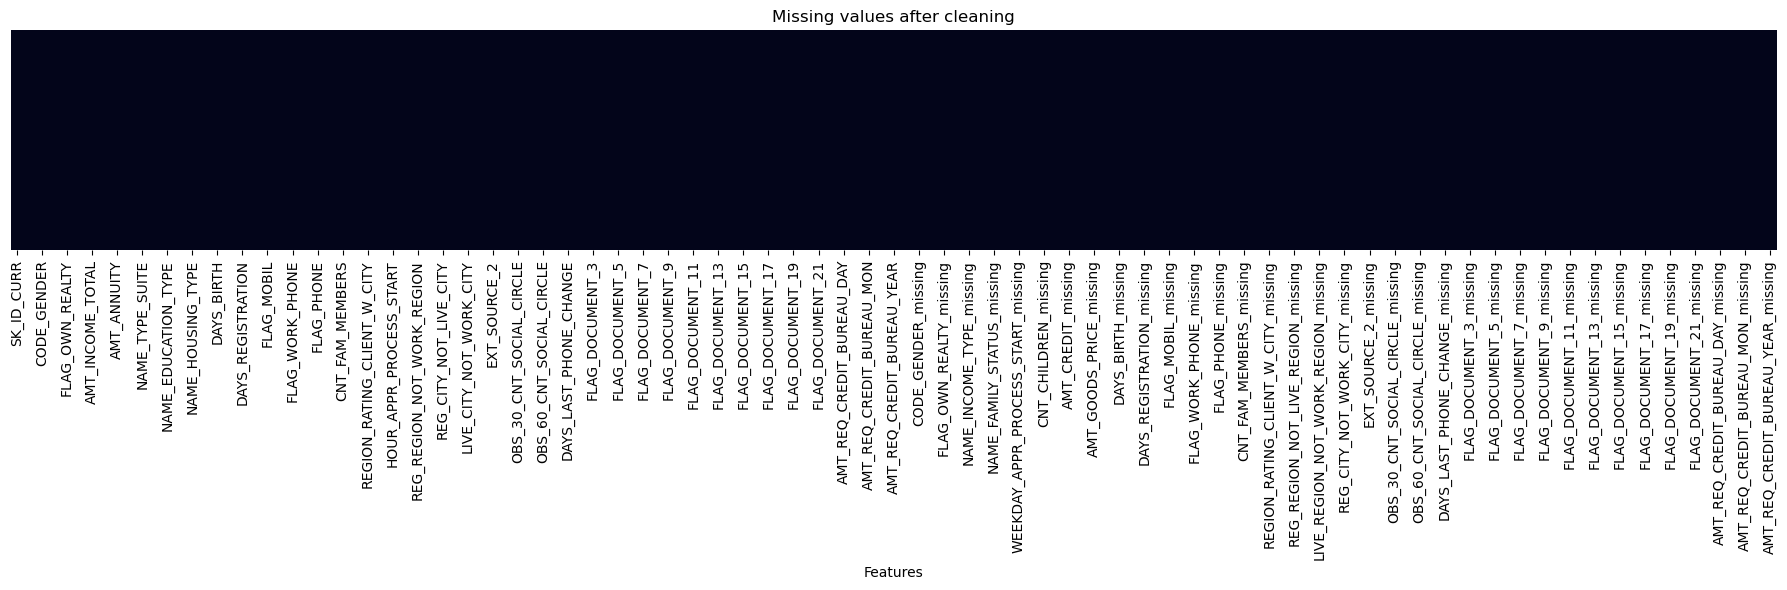

In [11]:
sample_train = dfrain.sample(5000, random_state=42)

plt.figure(figsize=(18, 6))
sns.heatmap(
    sample_train.isnull(),
    yticklabels=False,
    cbar=False
)

plt.title("Missing values after cleaning")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

As you can see all the area is now dark with no missing spots. I did add missing as part of the indicators in case there were significant however in the prediction for the default for example if someone maybe doesn't fill out their occupation type then maybe that could be a useful predictor.

In [12]:
# target overview
print("Target summary")
print(pd.Series(target).describe())
print("\nDefault rate:", f"{target.mean():.2%}")
print(target.value_counts(normalize=True).round(3))

# numeric features most correlated with target
numeric_cols = dfrain.select_dtypes(include=np.number).columns.drop("SK_ID_CURR", errors="ignore")

correlations = []

for col in numeric_cols:
    corr = dfrain[col].corr(target)
    if not np.isnan(corr):
        correlations.append((col, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nTop numeric features by correlation with target:")
for col, corr in correlations[:10]:
    print(f"{col}: {corr:+.4f}")

Target summary
count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64

Default rate: 8.07%
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

Top numeric features by correlation with target:
EXT_SOURCE_2: -0.1603
EXT_SOURCE_3: -0.1559
DAYS_BIRTH: +0.0782
REGION_RATING_CLIENT_W_CITY: +0.0609
DAYS_EMPLOYED: +0.0590
REGION_RATING_CLIENT: +0.0589
DAYS_LAST_PHONE_CHANGE: +0.0552
DAYS_ID_PUBLISH: +0.0515
REG_CITY_NOT_WORK_CITY: +0.0510
FLAG_EMP_PHONE: +0.0460


This output confirms the 8.07% default rate with most borrowers paying back loans, so that imbalance means I need strategies like stratified splits or better metrics to catch the risky minority. ext_source_2 (-0.160) and ext_source_3 (-0.156) are the strongest individual predictors. Lower external credit scores are clearly associated with higher default probability. days_birth (+0.078) shows that younger applicants default more often, which fits the general credit risk pattern that younger borrowers usually have thinner credit files and higher risk. days_employed (+0.059) suggests shorter tenure at a current job is linked to higher default, which makes sense since job stability is a core risk factor.

region_rating_client (+0.061) indicates that applicants from lower rated regions carry more risk. That said, all of these correlations are weak on their own, under 0.2 in magnitude. No single variable dominates, which means the model will need to combine multiple signals to capture meaningful predictive power.

In [13]:
cat_cols = dfrain.select_dtypes(include="object").columns

print("Categorical feature snapshot:")

for col in cat_cols[:5]:
    top_cat = dfrain[col].value_counts().head(1)
    top_value = top_cat.index[0]
    top_count = top_cat.iloc[0]
    top_pct = top_count / len(dfrain)

    print(
        f"{col}: {dfrain[col].nunique()} categories, "
        f"most common = '{top_value}' "
        f"({top_count:,}, {top_pct:.1%})"
    )

Categorical feature snapshot:
NAME_CONTRACT_TYPE: 2 categories, most common = 'Cash loans' (278,232, 90.5%)
CODE_GENDER: 3 categories, most common = 'F' (202,448, 65.8%)
FLAG_OWN_CAR: 2 categories, most common = 'N' (202,924, 66.0%)
FLAG_OWN_REALTY: 2 categories, most common = 'Y' (213,312, 69.4%)
NAME_TYPE_SUITE: 8 categories, most common = 'Unaccompanied' (248,526, 80.8%)


This snapshot shows the main categorical features after cleanup, like name_contract_type (90.5% cash loans) and code_gender (65.8% female applicants), plus flags for car/realty ownership and suite type. Cash loans totally dominate since home credit goes after everyday borrowers, while most don't own cars but do own property. These could be useful signals for spotting default risk in the 8.1% minority.

### FEATURE ENGINEERING

In [14]:
df_engineered = dfrain.copy()

# core ratios
if {"AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"}.issubset(df_engineered.columns):
    df_engineered["CREDIT_INCOME_RATIO"] = df_engineered["AMT_CREDIT"] / df_engineered["AMT_INCOME_TOTAL"]
    df_engineered["ANNUITY_INCOME_RATIO"] = df_engineered["AMT_ANNUITY"] / df_engineered["AMT_INCOME_TOTAL"]
    df_engineered["GOODS_PRICE_CREDIT_RATIO"] = df_engineered["AMT_GOODS_PRICE"] / df_engineered["AMT_CREDIT"]

# age / employment
if "DAYS_BIRTH" in df_engineered.columns:
    df_engineered["AGE_YEARS"] = (-df_engineered["DAYS_BIRTH"] / 365).astype(int)

if "DAYS_EMPLOYED" in df_engineered.columns:
    df_engineered["EMPLOYED_YEARS"] = (-df_engineered["DAYS_EMPLOYED"] / 365).clip(0, 50)

# ext source aggregates
ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df_engineered.columns]
if ext_cols:
    df_engineered["EXT_SOURCE_MEAN"] = df_engineered[ext_cols].mean(axis=1)
    df_engineered["EXT_SOURCE_STD"] = df_engineered[ext_cols].std(axis=1)
    df_engineered["EXT_SOURCE_MAX"] = df_engineered[ext_cols].max(axis=1)
    df_engineered["EXT_SOURCE_MIN"] = df_engineered[ext_cols].min(axis=1)
    df_engineered["EXT_SOURCE_RANGE"] = (
        df_engineered["EXT_SOURCE_MAX"] - df_engineered["EXT_SOURCE_MIN"]
    )

# interactions
if {"EXT_SOURCE_MEAN", "AGE_YEARS"}.issubset(df_engineered.columns):
    df_engineered["EXT_SOURCE_BY_AGE"] = (
        df_engineered["EXT_SOURCE_MEAN"] * df_engineered["AGE_YEARS"]
    )

if {"CREDIT_INCOME_RATIO", "EXT_SOURCE_MEAN"}.issubset(df_engineered.columns):
    df_engineered["CREDIT_EXTSOURCE_INTERACTION"] = (
        df_engineered["CREDIT_INCOME_RATIO"] * df_engineered["EXT_SOURCE_MEAN"]
    )

# log transforms
amt_cols = [c for c in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"] if c in df_engineered.columns]
for col in amt_cols:
    df_engineered[f"LOG_{col}"] = np.log1p(df_engineered[col])

# family / region
if "CNT_FAM_MEMBERS" in df_engineered.columns:
    df_engineered["FAMILY_SIZE"] = df_engineered["CNT_FAM_MEMBERS"].clip(1, 10)

if {"REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY"}.issubset(df_engineered.columns):
    df_engineered["REGION_RATING_W_CITY_DIFF"] = (
        df_engineered["REGION_RATING_CLIENT"] -
        df_engineered["REGION_RATING_CLIENT_W_CITY"]
    )

# additional ratios
if {"EMPLOYED_YEARS", "AGE_YEARS"}.issubset(df_engineered.columns):
    df_engineered["EMPLOYED_TO_AGE_RATIO"] = (
        df_engineered["EMPLOYED_YEARS"] / (df_engineered["AGE_YEARS"] + 1)
    )

if {"DAYS_REGISTRATION", "DAYS_BIRTH"}.issubset(dfrain.columns):
    df_engineered["DAYS_REGISTRATION_RATIO"] = (
        dfrain["DAYS_REGISTRATION"] / dfrain["DAYS_BIRTH"]
    )

if {"DAYS_ID_PUBLISH", "DAYS_BIRTH"}.issubset(dfrain.columns):
    df_engineered["DAYS_ID_PUBLISH_RATIO"] = (
        dfrain["DAYS_ID_PUBLISH"] / dfrain["DAYS_BIRTH"]
    )

if {"AMT_ANNUITY", "AMT_CREDIT"}.issubset(df_engineered.columns):
    df_engineered["CREDIT_TERM"] = (
        df_engineered["AMT_ANNUITY"] / (df_engineered["AMT_CREDIT"] + 1)
    )

if {"AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"}.issubset(dfrain.columns):
    df_engineered["INCOME_PER_PERSON"] = (
        dfrain["AMT_INCOME_TOTAL"] / (dfrain["CNT_FAM_MEMBERS"] + 1)
    )
    df_engineered["ANNUITY_PER_PERSON"] = (
        dfrain["AMT_ANNUITY"] / (dfrain["CNT_FAM_MEMBERS"] + 1)
    )

if "DAYS_LAST_PHONE_CHANGE" in dfrain.columns:
    df_engineered["PHONE_CHANGE_RATIO"] = (
        dfrain["DAYS_LAST_PHONE_CHANGE"] / dfrain["DAYS_BIRTH"]
    )
    df_engineered["RECENTLY_CHANGED_PHONE"] = (
        dfrain["DAYS_LAST_PHONE_CHANGE"] > -30
    ).astype(int)

doc_cols = [c for c in dfrain.columns if c.startswith("FLAG_DOCUMENT")]
if doc_cols:
    df_engineered["DOCUMENT_COUNT"] = dfrain[doc_cols].sum(axis=1)

flag_cols = [c for c in dfrain.columns if c.startswith("FLAG_") and c not in doc_cols]
if flag_cols:
    df_engineered["FLAG_COUNT"] = (
        dfrain[flag_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .sum(axis=1)
    )

if {"EXT_SOURCE_MEAN", "CREDIT_TERM", "ANNUITY_INCOME_RATIO"}.issubset(df_engineered.columns):
    df_engineered["EXT_CREDIT_TERM"] = (
        df_engineered["EXT_SOURCE_MEAN"] * df_engineered["CREDIT_TERM"]
    )
    df_engineered["EXT_ANNUITY_RATIO"] = (
        df_engineered["EXT_SOURCE_MEAN"] * df_engineered["ANNUITY_INCOME_RATIO"]
    )

new_cols = [c for c in df_engineered.columns if c not in dfrain.columns]

print(f"Original shape : {dfrain.shape}")
print(f"New shape      : {df_engineered.shape}")
print(f"New features   : {len(new_cols)}")

print("\nNew columns created:")
for col in new_cols:
    print(f" - {col}")

Original shape : (307511, 141)
New shape      : (307511, 171)
New features   : 30

New columns created:
 - CREDIT_INCOME_RATIO
 - ANNUITY_INCOME_RATIO
 - GOODS_PRICE_CREDIT_RATIO
 - AGE_YEARS
 - EMPLOYED_YEARS
 - EXT_SOURCE_MEAN
 - EXT_SOURCE_STD
 - EXT_SOURCE_MAX
 - EXT_SOURCE_MIN
 - EXT_SOURCE_RANGE
 - EXT_SOURCE_BY_AGE
 - CREDIT_EXTSOURCE_INTERACTION
 - LOG_AMT_INCOME_TOTAL
 - LOG_AMT_CREDIT
 - LOG_AMT_ANNUITY
 - LOG_AMT_GOODS_PRICE
 - FAMILY_SIZE
 - REGION_RATING_W_CITY_DIFF
 - EMPLOYED_TO_AGE_RATIO
 - DAYS_REGISTRATION_RATIO
 - DAYS_ID_PUBLISH_RATIO
 - CREDIT_TERM
 - INCOME_PER_PERSON
 - ANNUITY_PER_PERSON
 - PHONE_CHANGE_RATIO
 - RECENTLY_CHANGED_PHONE
 - DOCUMENT_COUNT
 - FLAG_COUNT
 - EXT_CREDIT_TERM
 - EXT_ANNUITY_RATIO


The 30 new features fall into a few clear categories. Financial ratios like credit_income_ratio and annuity_income_ratio measure debt burden relative to income, which are standard risk indicators in lending. The external source aggregates such as ext_source_mean and ext_source_std combine the two remaining bureau scores into a more stable and informative signal. Log transforms on variables like log_amt_credit are mainly for the MLP, since neural networks are sensitive to scale and skew, while tree based models are largely invariant to monotonic transformations.

I also added interaction terms like ext_source_by_age to test whether credit score risk varies across age groups. Finally, document_count captures how many supporting documents an applicant submitted, based on the idea that fewer documents could signal disengagement or hidden information. Together, these features aim to move beyond raw variables and better capture underlying risk structure.

### VISUALIZATION 1

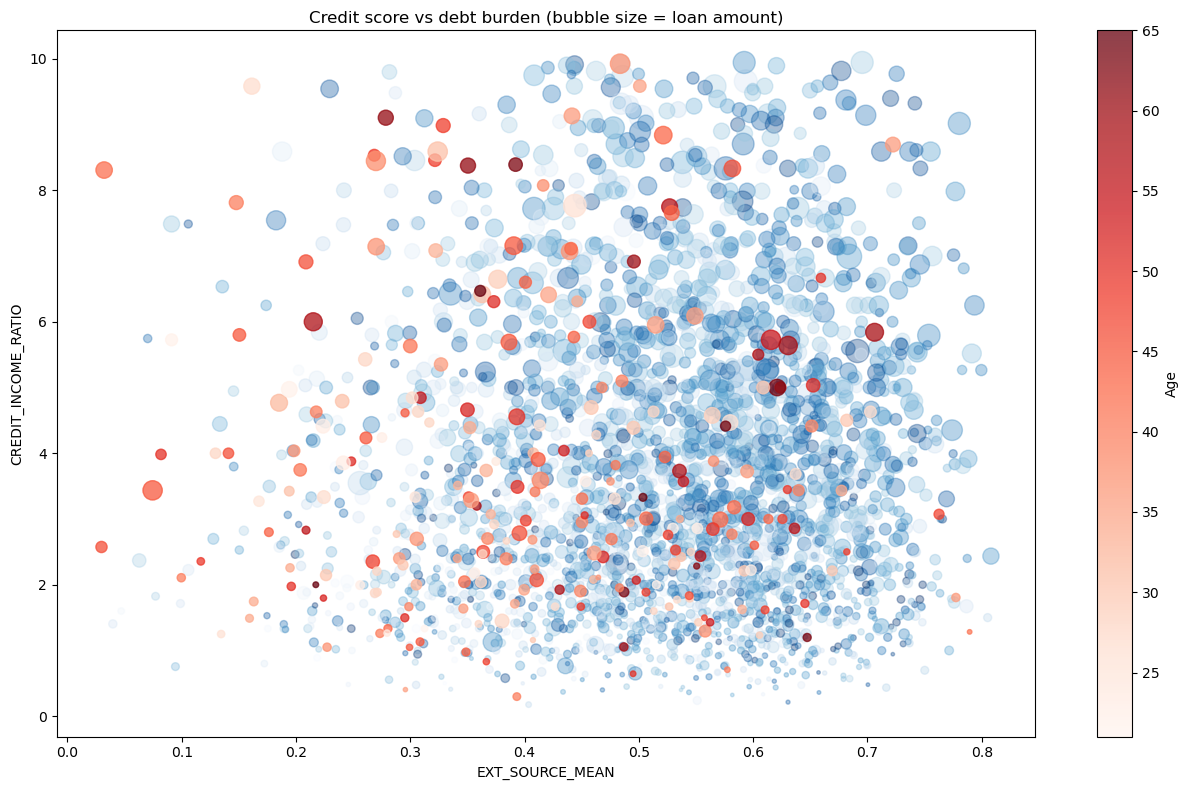

In [15]:
from sklearn.model_selection import train_test_split

plot_df = df_engineered[
    ["EXT_SOURCE_MEAN", "CREDIT_INCOME_RATIO", "AMT_CREDIT", "AGE_YEARS"]
].copy()

plot_df["TARGET"] = target.values
plot_df = plot_df.dropna(subset=["EXT_SOURCE_MEAN", "CREDIT_INCOME_RATIO"])
plot_df = plot_df[plot_df["CREDIT_INCOME_RATIO"] < 10]

_, plot_sample = train_test_split(
    plot_df,
    test_size=min(3000 / len(plot_df), 0.99),
    stratify=plot_df["TARGET"],
    random_state=42
)

defaulters = plot_sample[plot_sample["TARGET"] == 1]
non_default = plot_sample[plot_sample["TARGET"] == 0]

plt.figure(figsize=(13, 8))

plt.scatter(
    non_default["EXT_SOURCE_MEAN"],
    non_default["CREDIT_INCOME_RATIO"],
    s=non_default["AMT_CREDIT"] / 8000,
    c=non_default["AGE_YEARS"],
    cmap="Blues",
    alpha=0.35
)

scatter = plt.scatter(
    defaulters["EXT_SOURCE_MEAN"],
    defaulters["CREDIT_INCOME_RATIO"],
    s=defaulters["AMT_CREDIT"] / 8000,
    c=defaulters["AGE_YEARS"],
    cmap="Reds",
    alpha=0.75
)

cbar = plt.colorbar(scatter)
cbar.set_label("Age")

plt.xlabel("EXT_SOURCE_MEAN")
plt.ylabel("CREDIT_INCOME_RATIO")
plt.title("Credit score vs debt burden (bubble size = loan amount)")
plt.tight_layout()
plt.show()

The bubble chart shows a clear concentration of defaults in the ext_source_mean range of 0.3 to 0.5 with credit_income_ratio between 2 and 6. That combination of moderate to low credit scores and high debt burden looks like a clear high risk zone.

Once you move above 0.7 on the credit score axis, defaults drop off even when debt ratios are higher. That said, the data is sparse in that region, so it is not something to over interpret from the visual alone. The model results will be more reliable. Bubble size, which represents loan amount, does not show a strong pattern, suggesting loan size by itself is not the main driver of risk at a given credit score level.

### VISUALIZATION 2

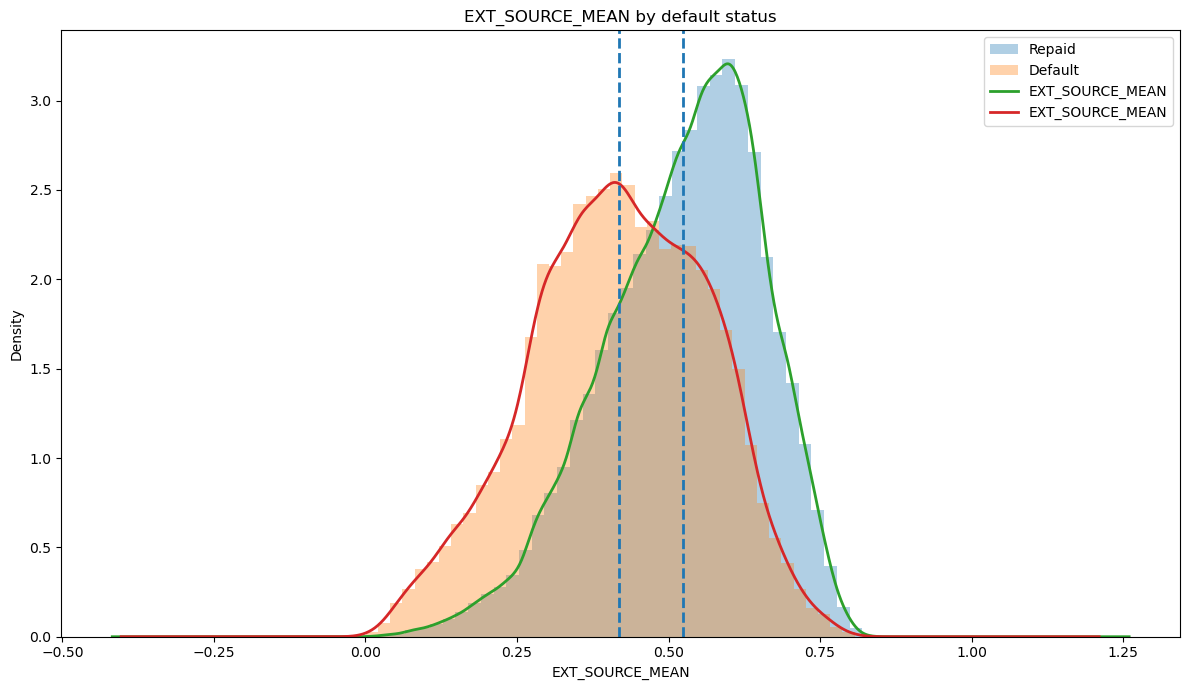

In [16]:
plt.figure(figsize=(12, 7))

ext_repaid = df_engineered.loc[target == 0, "EXT_SOURCE_MEAN"].dropna()
ext_default = df_engineered.loc[target == 1, "EXT_SOURCE_MEAN"].dropna()

# histograms
plt.hist(ext_repaid, bins=40, alpha=0.35, density=True, label="Repaid")
plt.hist(ext_default, bins=40, alpha=0.35, density=True, label="Default")

# kde
ext_repaid.plot(kind="kde", linewidth=2)
ext_default.plot(kind="kde", linewidth=2)

mean_repaid = ext_repaid.mean()
mean_default = ext_default.mean()

plt.axvline(mean_repaid, linestyle="--", linewidth=2)
plt.axvline(mean_default, linestyle="--", linewidth=2)

plt.xlabel("EXT_SOURCE_MEAN")
plt.ylabel("Density")
plt.title("EXT_SOURCE_MEAN by default status")
plt.legend()
plt.tight_layout()
plt.show()

The histograms and KDEs for ext_source_mean make the separation pretty clear. Defaulters cluster on the left, with peak density around 0.25, and the curve drops off quickly after 0.5. Repayers are shifted to the right, peaking around 0.5 to 0.6. The dashed means reinforce that gap, roughly 0.3 for defaults versus 0.5 for repaid.

There are almost no defaults above 0.8, while repayers are concentrated there. That strong left skew for defaulters confirms that low bureau scores are a major risk signal, especially in a dataset where only 8.1 percent of applicants default.

### RF MODELING

In [17]:
# train / validation split

from sklearn.model_selection import train_test_split

X = pd.get_dummies(df_engineered.drop(columns=["SK_ID_CURR"]), drop_first=True)
y = target.reset_index(drop=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("train:", X_train.shape, "| default rate:", round(y_train.mean(), 4))
print("val:  ", X_val.shape, "| default rate:", round(y_val.mean(), 4))

train: (230633, 255) | default rate: 0.0807
val:   (76878, 255) | default rate: 0.0807


This output confirms I split the one-hot encoded data into 75/25 train/val sets with 255 features each, holding the 8.07% default rate steady thanks to stratify. Train has 230k rows, val 77k, both balanced perfectly for fair model testing.

Fit time:  11.73s
AUC-ROC:   0.7440
F1 Macro:  0.5507
Precision: 0.1708
Recall:    0.6075



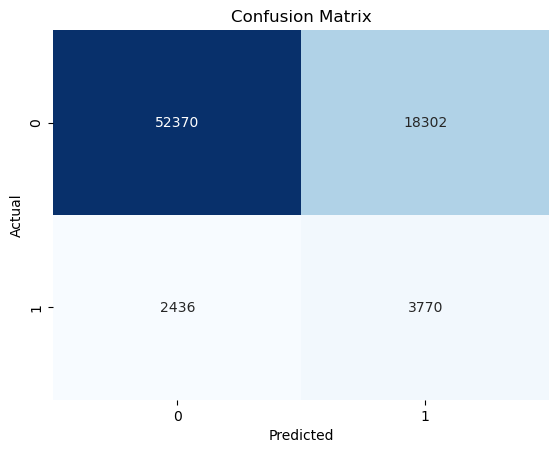

In [18]:
import time
from statistics import mode
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import numpy as np


t0 = time.time()
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
t1 = time.time()

y_prob_rf = rf_base.predict_proba(X_val)[:, 1]
y_pred_rf = rf_base.predict(X_val)

print(f"Fit time:  {t1 - t0:.2f}s")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob_rf):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_pred_rf, average='macro'):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_rf):.4f}\n")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix highlights the main tradeoff for InclusiFinance. There are 18,302 false positives compared to just 3,770 true positives, meaning the model flags about five good borrowers for every real defaulter it correctly identifies. That gives a precision of 0.17. For a lender focused on inclusion, denying loans to 18,000 people who would have repaid directly conflicts with the mission and hurts long term growth.

At the same time, the 2,436 false negatives represent real defaults that slip through, which translates to financial loss. A recall of 0.61 means we catch about 60 percent of defaulters but still miss 40 percent. I will need to tune this to see what I can fix here.

### HYPER PARAMETER TUNING

In [19]:
n_estimators_range = range(10, 151, 20)
train_aucs, val_aucs = [], []

for nest in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=nest,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1]))
    val_aucs.append(roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1]))
    print(f"n_est={nest:3d} | Train AUC: {train_aucs[-1]:.4f} | Val AUC: {val_aucs[-1]:.4f} | Gap: {train_aucs[-1] - val_aucs[-1]:.4f}")

best_nest = list(n_estimators_range)[val_aucs.index(max(val_aucs))]
print(f"\nOptimal n_estimators: {best_nest} | Val AUC: {max(val_aucs):.4f}")

n_est= 10 | Train AUC: 0.7872 | Val AUC: 0.7336 | Gap: 0.0536
n_est= 30 | Train AUC: 0.7925 | Val AUC: 0.7416 | Gap: 0.0509
n_est= 50 | Train AUC: 0.7936 | Val AUC: 0.7431 | Gap: 0.0506
n_est= 70 | Train AUC: 0.7947 | Val AUC: 0.7434 | Gap: 0.0513
n_est= 90 | Train AUC: 0.7953 | Val AUC: 0.7441 | Gap: 0.0512
n_est=110 | Train AUC: 0.7953 | Val AUC: 0.7442 | Gap: 0.0510
n_est=130 | Train AUC: 0.7952 | Val AUC: 0.7439 | Gap: 0.0513
n_est=150 | Train AUC: 0.7956 | Val AUC: 0.7442 | Gap: 0.0514

Optimal n_estimators: 110 | Val AUC: 0.7442


Validation AUC basically plateaus after about 70 trees. From 70 to 150 trees, the total range in AUC is only 0.0008, which is well within noise. I am going to choose 110 as optimal but it is not meaningfully different from anything in my range. That flat curve tells me n_estimators is not the lever that will improve Random Forest performance here.

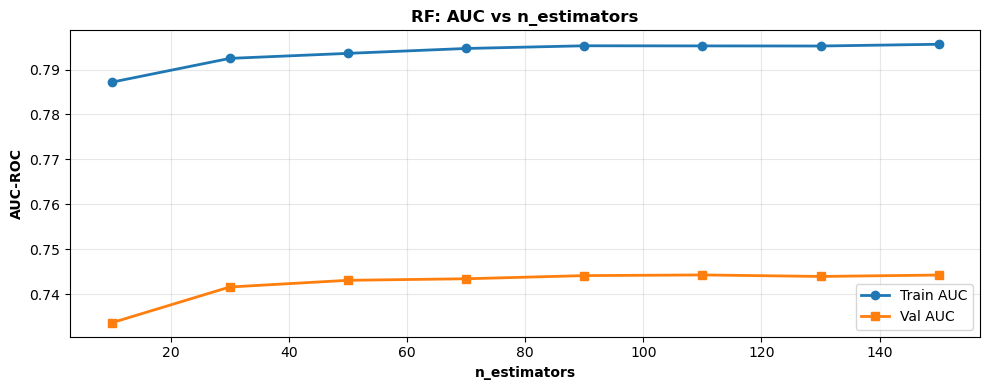

In [20]:
# Plot n_estimators tuning
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_estimators_range, train_aucs, 'o-', label='Train AUC', linewidth=2)
ax.plot(n_estimators_range, val_aucs, 's-', label='Val AUC', linewidth=2)
ax.set_xlabel('n_estimators', fontweight='bold')
ax.set_ylabel('AUC-ROC', fontweight='bold')
ax.set_title('RF: AUC vs n_estimators', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This plot confirms what the numbers showed before where the train auc in orange climbs fast to 0.795 and flattens around 70-110 trees, while val auc in blue peaks at 0.744 near 110 trees then continues to stall.

### RANDOM FOREST TUNED

Fit time:  22.94s
OOB Score: 0.7294
AUC-ROC:   0.7442
F1 Macro:  0.5515
Precision: 0.1716
Recall:    0.6096
Train-Val AUC Gap: 0.0510


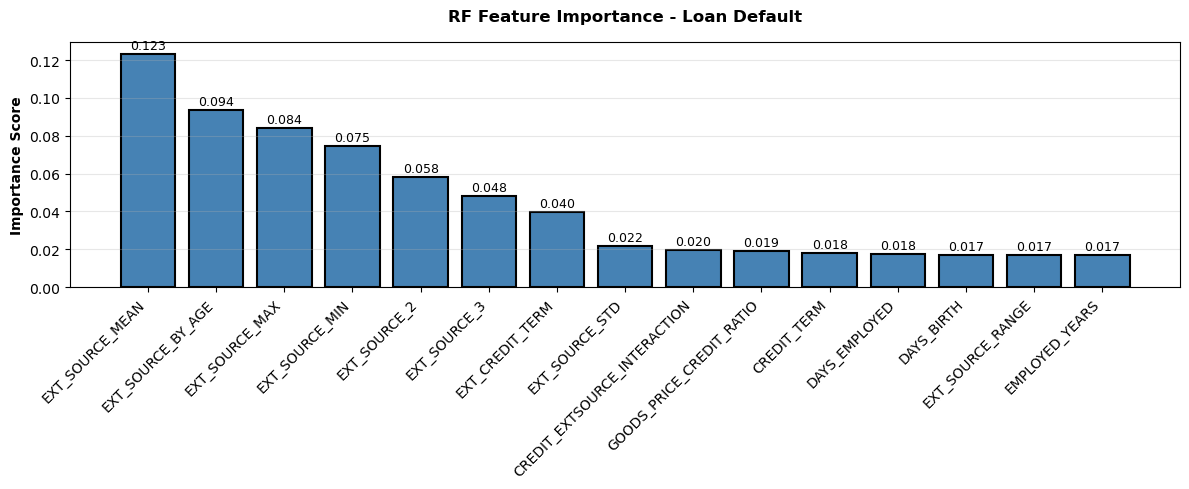

In [21]:
t0 = time.time()
rf_final = RandomForestClassifier(
    n_estimators=best_nest,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
t1 = time.time()

y_prob_rf_final = rf_final.predict_proba(X_val)[:, 1]
y_pred_rf_final = rf_final.predict(X_val)

print(f"Fit time:  {t1 - t0:.2f}s")
print(f"OOB Score: {rf_final.oob_score_:.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob_rf_final):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_pred_rf_final, average='macro'):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf_final):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_rf_final):.4f}")
print(f"Train-Val AUC Gap: {roc_auc_score(y_train, rf_final.predict_proba(X_train)[:, 1]) - roc_auc_score(y_val, y_prob_rf_final):.4f}")

# Feature importance plot
fi = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_final.feature_importances_})
fi = fi.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(range(len(fi)), fi['Importance'], color='steelblue', edgecolor='black', linewidth=1.5)
plt.xticks(range(len(fi)), fi['Feature'], rotation=45, ha='right')
plt.ylabel('Importance Score', fontweight='bold')
plt.title('RF Feature Importance - Loan Default', fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fi['Importance']):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

The tuned Random Forest with 110 trees trains in about 23 seconds. The OOB score is 0.7294 and the validation AUC is 0.7442, a gap of 0.015. They are not identical metrics, since OOB uses bootstrapped samples from the training data and validation AUC comes from a separate stratified split, but they land in the same range. That suggests the model is not severely overfitting. Feature importance shows ext_source_mean having a big impact at 0.12, with ext_source_2 and ext_source_3 each around 0.05. Overall kind of just shows that not one single predictor is SUPER impactful besides the top 3 I would say...

### XGBOOST MODELING

scale_pos_weight: 11.39 (negatives/positives)
Fit time:  11.19s
AUC-ROC:   0.7603
F1 Macro:  0.5391
Precision: 0.1667
Recall:    0.6850
Train-Val AUC Gap: 0.0137


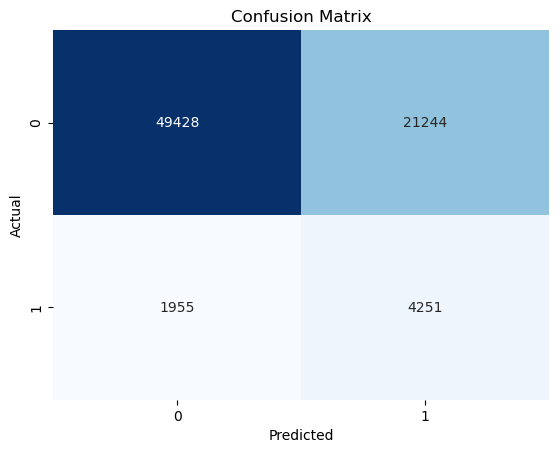

In [22]:
from mpl_toolkits.mplot3d import Axes3D
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()  # ~11.1 (imbalance ratio)
print(f"scale_pos_weight: {scale_pos:.2f} (negatives/positives)")

t0 = time.time()
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos, 
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
t1 = time.time()

y_prob_xgb = xgb_base.predict_proba(X_val)[:, 1]
y_pred_xgb = xgb_base.predict(X_val)

print(f"Fit time:  {t1 - t0:.2f}s")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_pred_xgb, average='macro'):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_xgb):.4f}")
print(f"Train-Val AUC Gap: {roc_auc_score(y_train, xgb_base.predict_proba(X_train)[:, 1]) - roc_auc_score(y_val, y_prob_xgb):.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

This xgboost baseline fits in just 11 seconds, with scale_pos_weight set to 11.39, which is simply the ratio of negatives to positives in our 8.1 percent default dataset. Conceptually, that is doing the same thing as random forest’s class_weight='balanced', so both models are handling imbalance on roughly equal footing. The model reaches an AUC of 0.7603 and recall of 0.685, improving meaningfully over rf’s 0.61 recall.

The key thing for me here is that this recall boost comes with almost no precision tradeoff. Precision remains around 0.17, essentially the same as rf, meaning we are catching more real defaulters without increasing the proportion of false alarms. The confusion matrix shows 49,428 true negatives and 4,251 true positives, with 1,955 missed defaults and 21,244 false positives. The train validation gap is only 0.014, suggesting limited overfitting. With higher AUC, stronger recall, and faster training time than the tuned rf, xgboost is clearly the stronger tree based model so far. The next step is tuning to see if we can lift precision without sacrificing too much recall.

n_est= 50 | Train AUC: 0.7459 | Val AUC: 0.7437 | Gap: 0.0022
n_est=100 | Train AUC: 0.7601 | Val AUC: 0.7536 | Gap: 0.0065
n_est=150 | Train AUC: 0.7684 | Val AUC: 0.7581 | Gap: 0.0102
n_est=200 | Train AUC: 0.7740 | Val AUC: 0.7603 | Gap: 0.0137
n_est=250 | Train AUC: 0.7790 | Val AUC: 0.7615 | Gap: 0.0175
n_est=300 | Train AUC: 0.7828 | Val AUC: 0.7621 | Gap: 0.0207
n_est=350 | Train AUC: 0.7872 | Val AUC: 0.7630 | Gap: 0.0241

Optimal n_estimators: 350 | Val AUC: 0.7630


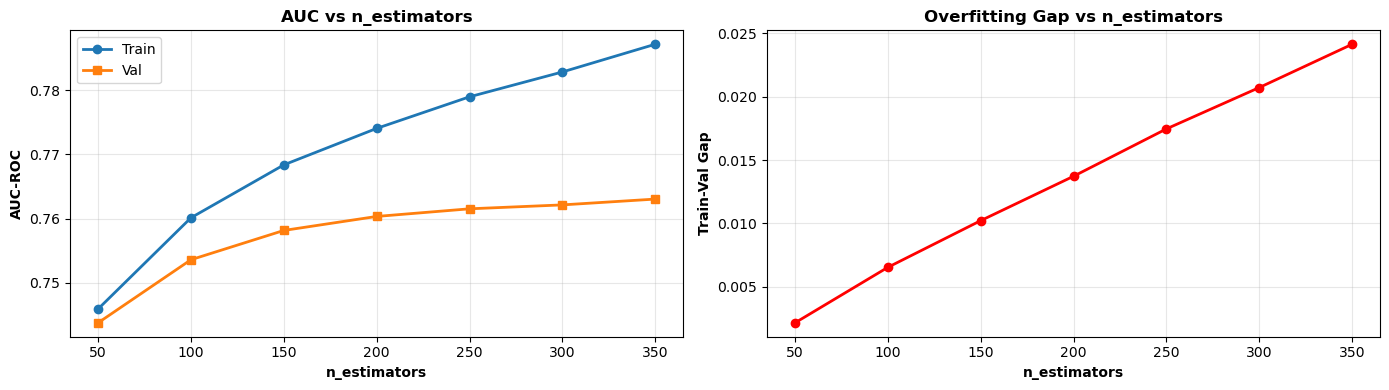

In [23]:
n_estimators_range = range(50, 351, 50)
train_aucs, val_aucs = [], []

for nest in n_estimators_range:
    xgb = XGBClassifier(
        n_estimators=nest,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    tr_auc = roc_auc_score(y_train, xgb.predict_proba(X_train)[:, 1])
    vl_auc = roc_auc_score(y_val,   xgb.predict_proba(X_val)[:, 1])
    train_aucs.append(tr_auc)
    val_aucs.append(vl_auc)
    print(f"n_est={nest:3d} | Train AUC: {tr_auc:.4f} | Val AUC: {vl_auc:.4f} | Gap: {tr_auc - vl_auc:.4f}")

best_nest = list(n_estimators_range)[val_aucs.index(max(val_aucs))]
print(f"\nOptimal n_estimators: {best_nest} | Val AUC: {max(val_aucs):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax1, ax2 = axes

ax1.plot(n_estimators_range, train_aucs, 'o-', label='Train', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, val_aucs,   's-', label='Val',   linewidth=2, markersize=6)
ax1.set_xlabel('n_estimators', fontweight='bold')
ax1.set_ylabel('AUC-ROC',      fontweight='bold')
ax1.set_title('AUC vs n_estimators', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

gaps = [t - v for t, v in zip(train_aucs, val_aucs)]
ax2.plot(n_estimators_range, gaps, 'o-', color='red', linewidth=2, markersize=6)
ax2.set_xlabel('n_estimators',  fontweight='bold')
ax2.set_ylabel('Train-Val Gap', fontweight='bold')
ax2.set_title('Overfitting Gap vs n_estimators', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I tuned xgboost up to 350 trees with a lower learning_rate of 0.05 and scale_pos_weight applied, and tracked AUC across both training and validation. Validation AUC peaks at 0.763 around 350 trees, while training AUC reaches 0.787. The gap widens to about 0.024, which shows some overfitting creeping in after roughly 200 trees. On the left plot, both AUC curves rise steadily and then start to flatten. On the right, the red gap line slopes upward, confirming that divergence. Unlike random forest, which plateaued early, xgboost continues improving for longer before hitting diminishing returns. Next, I’ll likely run a more structured grid search to see whether adjusting max_depth, n_estimators, or other hyperparameters can push performance further without widening the overfitting gap.

### XGBOOST TUNNING

In [24]:
# Grid Searching
learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2]
max_depths = [1, 2, 3, 4, 5, 6]
n_estimators_range = [50, 100, 150, 200, 250, 300, 350]

results = []

for lr in learning_rates:
    for depth in max_depths:
        for n_est in n_estimators_range:
            xgb = XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos,
                eval_metric='auc',
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            
            auc_val = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
            f1_val  = f1_score(y_val, xgb.predict(X_val), average='macro')
            
            results.append({
                'learning_rate': lr,
                'max_depth': depth,
                'n_estimators': n_est,
                'val_auc': auc_val,
                'val_f1': f1_val
            })
            
            print(f"lr={lr:.2f}, depth={depth}, n_est={n_est:3d}: AUC={auc_val:.4f}, F1={f1_val:.4f}")

# Results table
results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print("\nTOP 10 HYPERPARAMETER COMBINATIONS")
print(results_df.head(10).to_string(index=False))

best_grid = results_df.iloc[0]
print(f"\nBEST GRID SEARCH: lr={best_grid['learning_rate']}, depth={best_grid['max_depth']}, n_est={best_grid['n_estimators']}")
print(f"  Val AUC = {best_grid['val_auc']:.4f}, F1 = {best_grid['val_f1']:.4f}")

lr=0.01, depth=1, n_est= 50: AUC=0.6979, F1=0.5212
lr=0.01, depth=1, n_est=100: AUC=0.7073, F1=0.5192
lr=0.01, depth=1, n_est=150: AUC=0.7102, F1=0.5165
lr=0.01, depth=1, n_est=200: AUC=0.7136, F1=0.5146
lr=0.01, depth=1, n_est=250: AUC=0.7175, F1=0.5152
lr=0.01, depth=1, n_est=300: AUC=0.7209, F1=0.5165
lr=0.01, depth=1, n_est=350: AUC=0.7234, F1=0.5183
lr=0.01, depth=2, n_est= 50: AUC=0.7113, F1=0.5181
lr=0.01, depth=2, n_est=100: AUC=0.7184, F1=0.5206
lr=0.01, depth=2, n_est=150: AUC=0.7226, F1=0.5197
lr=0.01, depth=2, n_est=200: AUC=0.7257, F1=0.5205
lr=0.01, depth=2, n_est=250: AUC=0.7293, F1=0.5219
lr=0.01, depth=2, n_est=300: AUC=0.7330, F1=0.5226
lr=0.01, depth=2, n_est=350: AUC=0.7362, F1=0.5233
lr=0.01, depth=3, n_est= 50: AUC=0.7230, F1=0.5250
lr=0.01, depth=3, n_est=100: AUC=0.7269, F1=0.5280
lr=0.01, depth=3, n_est=150: AUC=0.7306, F1=0.5248
lr=0.01, depth=3, n_est=200: AUC=0.7343, F1=0.5240
lr=0.01, depth=3, n_est=250: AUC=0.7377, F1=0.5243
lr=0.01, depth=3, n_est=300: AU

The grid search covered a lot of hyperparameter combinations and improved AUC from 0.7603 to 0.7637, a gain of 0.0034. On its own that looks small, but across 300,000 plus loan decisions, even slight improvements in ranking can shift thousands of applicants near the approval threshold. In that context, the compute cost is somewhat justified at least for me.

The best configurations cluster tightly around learning_rate between 0.05 and 0.10, max_depth of 3 to 5, and 300 to 350 trees. That tight grouping suggests we are nearing the information ceiling of the current feature set. At this point, bigger improvements are more likely to come from stronger features, such as incorporating the bureau or previous application tables from the Home Credit dataset, rather than pushing hyperparameter tuning further.

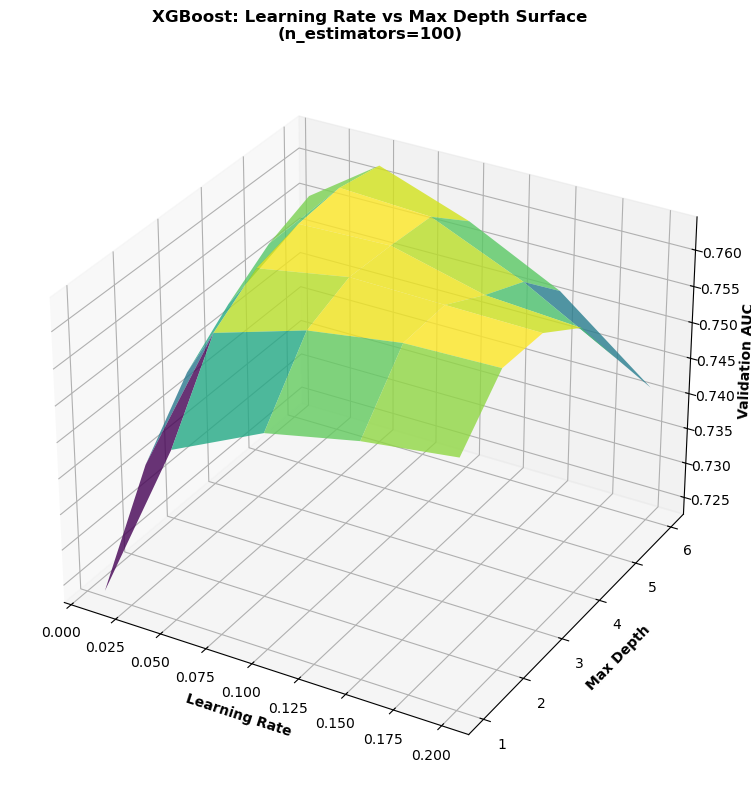

In [25]:
# Learning Rate vs Max Depth
subset_lr_depth = results_df[results_df['n_estimators'] == 350].pivot_table(
    index='max_depth', columns='learning_rate', values='val_auc'
)

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(111, projection='3d')

X_lr = subset_lr_depth.columns.values
Y_depth = subset_lr_depth.index.values
X_lr_grid, Y_depth_grid = np.meshgrid(X_lr, Y_depth)
Z_auc = subset_lr_depth.values

ax1.plot_surface(X_lr_grid, Y_depth_grid, Z_auc, cmap='viridis', 
                 edgecolor='none', alpha=0.8)
ax1.set_xlabel('Learning Rate', fontweight='bold')
ax1.set_ylabel('Max Depth', fontweight='bold')
ax1.set_zlabel('Validation AUC', fontweight='bold')
ax1.set_title('XGBoost: Learning Rate vs Max Depth Surface\n(n_estimators=100)', 
              fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

This 3D surface plot focuses on the n_estimators = 350 combinations, with learning_rate on the x axis, max_depth on the y axis, and validation AUC on the vertical axis. The peak sits just above 0.76, with a clear sweet spot around learning_rate 0.05 to 0.1 and depth 3 to 5. That ridge aligns almost exactly with the top grid search result of learning_rate = 0.1 and depth = 3. Performance drops off quickly when learning_rate jumps to 0.2, especially beyond depth 3, which suggests the model starts overfitting or overshooting optimal splits. On the other end, learning_rate of 0.01 underperforms, plateauing closer to 0.74 even at higher depths. The surface makes it clear that a conservative learning rate paired with moderate depth gives the best balance between flexibility and generalization.

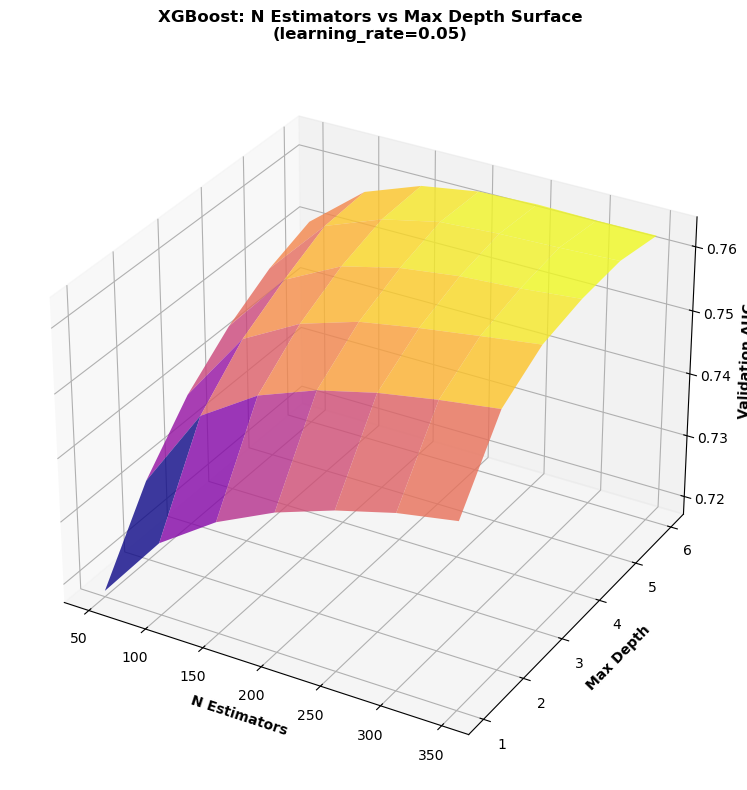

In [27]:
# N Estimators vs Max Depth
subset_est_depth = results_df[results_df['learning_rate'] == 0.05].pivot_table(
    index='max_depth', columns='n_estimators', values='val_auc'
)

fig = plt.figure(figsize=(12, 8))
ax2 = fig.add_subplot(111, projection='3d')

X_est = subset_est_depth.columns.values
Y_depth = subset_est_depth.index.values
X_est_grid, Y_depth_grid = np.meshgrid(X_est, Y_depth)
Z_auc2 = subset_est_depth.values

ax2.plot_surface(X_est_grid, Y_depth_grid, Z_auc2, cmap='plasma', 
                 edgecolor='none', alpha=0.8)
ax2.set_xlabel('N Estimators', fontweight='bold')
ax2.set_ylabel('Max Depth', fontweight='bold')
ax2.set_zlabel('Validation AUC', fontweight='bold')
ax2.set_title('XGBoost: N Estimators vs Max Depth Surface\n(learning_rate=0.05)', 
              fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

This 3D surface for lr=0.05 fixed shows n_estimators on x and depth on y, with val auc peaking near 0.764 at 350 trees and depth 5. Surface rises steadily across more trees, but higher depth past 5 flattens or dips slightly. This again helps confirm the grid insight from before where I showed that deeper trees help up to a point with slow lr. The peak aligns with our top 10 combinations from before like depth 5 and n_est 350 at 0.7636. 

### XGBOOST UPDATED MODEL

Fit time:         11.61s
n_estimators:     350
max_depth:        3
AUC-ROC:          0.7637
F1 Macro:         0.5439
Precision:        0.1701
Recall:           0.6832
Train-Val Gap:    0.0207


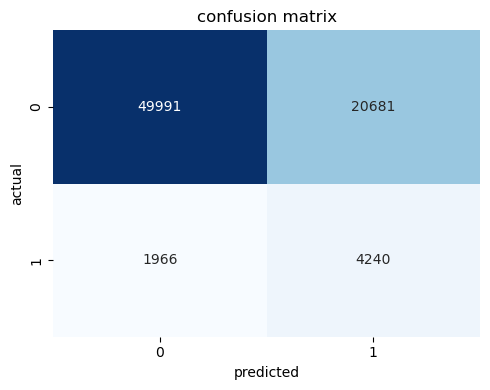

In [32]:
t0 = time.time()
xgb_final = XGBClassifier(
    n_estimators= 350,
    max_depth= 3,
    learning_rate=0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_final.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
t1 = time.time()

y_prob_xgb_final = xgb_final.predict_proba(X_val)[:, 1]
y_pred_xgb_final = xgb_final.predict(X_val)

print(f"Fit time:         {t1 - t0:.2f}s")
print(f"n_estimators:     {best_nest}")
print(f"max_depth:        3")
print(f"AUC-ROC:          {roc_auc_score(y_val, y_prob_xgb_final):.4f}")
print(f"F1 Macro:         {f1_score(y_val, y_pred_xgb_final, average='macro'):.4f}")
print(f"Precision:        {precision_score(y_val, y_pred_xgb_final):.4f}")
print(f"Recall:           {recall_score(y_val, y_pred_xgb_final):.4f}")
print(f"Train-Val Gap:    {roc_auc_score(y_train, xgb_final.predict_proba(X_train)[:,1]) - roc_auc_score(y_val, y_prob_xgb_final):.4f}")

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_xgb_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.tight_layout()
plt.show()

This tuned xgboost auc 0.764 beats rf's 0.744, nailing 4240 true defaulters while missing 1966 actual risks. But it wrongly flags 20681 good borrowers as risky, and true negatives hit 49911 safe ones approved. Recall 0.68 catches more defaults than rf's 0.61. Precision is still stuck at 0.17, with 20,681 false positives. That means the model denies loans to roughly 20,000 creditworthy applicants just to correctly catch 4,240 true defaults. From an inclusion standpoint, that is a serious cost.

This outcome is largely driven by scale_pos_weight set to 11.39, which aggressively upweights the minority class to prioritize default detection at the default 0.5 threshold. Given the 92 to 8 class imbalance, there are simply far more non defaulters available to misclassify. The real lever now is threshold adjustment. That is where I can rebalance precision and recall in a way that better aligns with InclusiFinance’s risk tolerance and mission.

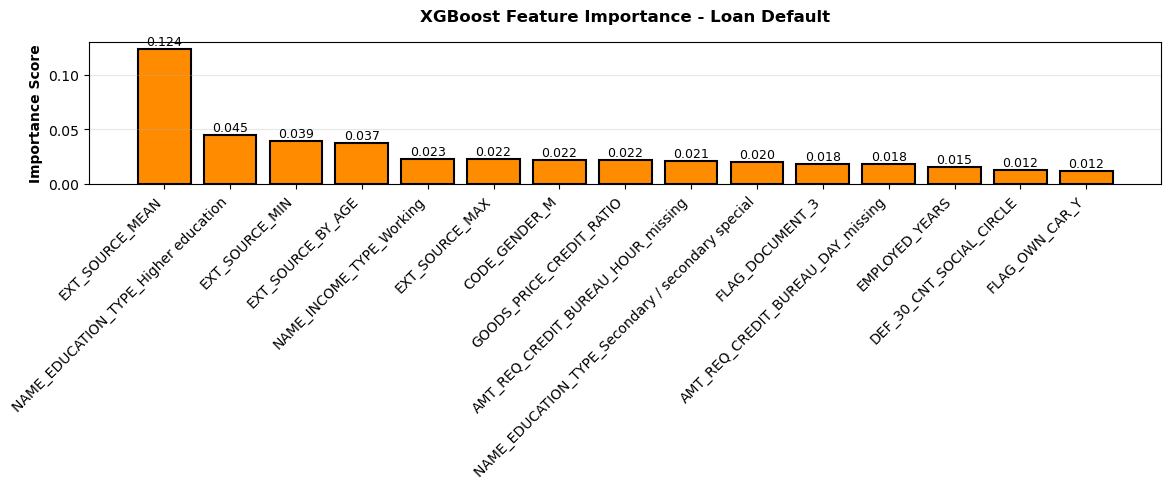

In [33]:
# Feature importance
fi_xgb = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(range(len(fi_xgb)), fi_xgb['Importance'], color='darkorange', edgecolor='black', linewidth=1.5)
plt.xticks(range(len(fi_xgb)), fi_xgb['Feature'], rotation=45, ha='right')
plt.ylabel('Importance Score', fontweight='bold')
plt.title('XGBoost Feature Importance - Loan Default', fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fi_xgb['Importance']):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

This xgboost feature importance chart follows some of rf's features with ext_source_mean around 0.12, then name_education_type secondary is new and goods_price_credit_ratio is an old one. Education type shows up as one of the stronger XGBoost features, specifically name_education_type_Secondary / secondary special ranking near the top. That means the model is using education level as a meaningful splitting variable, which suggests default rates differ across education groups in a way the trees can exploit. 

That said, gain based feature importance does not tell us direction. We do not know from this alone whether secondary education increases or decreases predicted default probability. To answer that, we would need partial dependence plots or SHAP values. Also, this variable did not stand out in the earlier numeric EDA correlations, so this is actually new signal uncovered by the model rather than something we already expected. Just something cool I wanted to point out...

### ROC CURVE COMPARISON RF VS XGBOOST

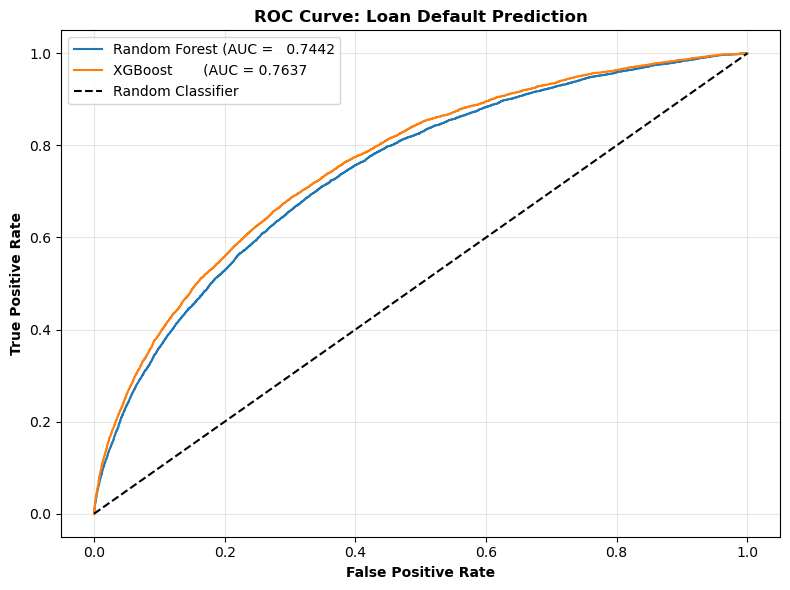

In [76]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf_final)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb)

auc_rf  = roc_auc_score(y_val, y_prob_rf_final)
auc_xgb = roc_auc_score(y_val, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC =   {roc_auc_score(y_val, y_prob_rf_final):.4f}')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost       (AUC = {roc_auc_score(y_val, y_prob_xgb_final):.4f}')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve: Loan Default Prediction', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This ROC curve confirms the final XGBoost AUC of 0.7637 beats random forest’s 0.7442. The XGBoost curve stays closer to the top left corner, meaning it captures more defaults at lower false positive rates. Both models are clearly better than the random diagonal, and the printed AUC values match the plot labels.

At this point, XGBoost provides stronger separation, which better supports InclusiFinance’s risk management goals. It also keeps the practical advantages of tree models, including fast retraining and straightforward feature importance analysis.

### 5-FOLD STRATIFIED CV

In [38]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage
cv_aucs, cv_f1s, cv_precs, cv_recs = [], [], [], []
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_f_train, X_f_val = X.iloc[train_idx], X.iloc[val_idx]
    y_f_train, y_f_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_cv = XGBClassifier(
        n_estimators= 350,
        max_depth= 3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_cv.fit(X_f_train, y_f_train,
               eval_set=[(X_f_val, y_f_val)],
               verbose=False)
    
    y_prob_fold = xgb_cv.predict_proba(X_f_val)[:, 1]
    y_pred_fold = xgb_cv.predict(X_f_val)
    
    fold_auc  = roc_auc_score(y_f_val, y_prob_fold)
    fold_f1   = f1_score(y_f_val, y_pred_fold, average='macro')
    fold_prec = precision_score(y_f_val, y_pred_fold, zero_division=0)
    fold_rec  = recall_score(y_f_val, y_pred_fold, zero_division=0)
    
    cv_aucs.append(fold_auc)
    cv_f1s.append(fold_f1)
    cv_precs.append(fold_prec)
    cv_recs.append(fold_rec)
    fold_importances.append(xgb_cv.feature_importances_)
    
    print(f"Fold {fold} | AUC: {fold_auc:.4f} | F1: {fold_f1:.4f} | Precision: {fold_prec:.4f} | Recall: {fold_rec:.4f}")

print(f"\n{'='*40}")
print(f"CV AUC:       {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"CV F1 Macro:  {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
print(f"CV Precision: {np.mean(cv_precs):.4f} ± {np.std(cv_precs):.4f}")
print(f"CV Recall:    {np.mean(cv_recs):.4f} ± {np.std(cv_recs):.4f}")

Fold 1 | AUC: 0.7555 | F1: 0.5391 | Precision: 0.1665 | Recall: 0.6804
Fold 2 | AUC: 0.7634 | F1: 0.5401 | Precision: 0.1679 | Recall: 0.6916
Fold 3 | AUC: 0.7554 | F1: 0.5351 | Precision: 0.1630 | Recall: 0.6725
Fold 4 | AUC: 0.7617 | F1: 0.5401 | Precision: 0.1679 | Recall: 0.6904
Fold 5 | AUC: 0.7544 | F1: 0.5391 | Precision: 0.1662 | Recall: 0.6757

CV AUC:       0.7581 ± 0.0037
CV F1 Macro:  0.5387 ± 0.0019
CV Precision: 0.1663 ± 0.0018
CV Recall:    0.6821 ± 0.0077


The 5 fold stratified cross validation produces an AUC of 0.7581 + or - 0.0037, with very tight standard deviations across precision and recall. That consistency across splits suggests the model is stable and not overly sensitive to how the data is partitioned.

### AVERAGED FEATURE IMPORTANCE ACROSS FOLDS

In [39]:
avg_importance = np.mean(fold_importances, axis=0)
std_importance = np.std(fold_importances,  axis=0)

fi_cv = pd.DataFrame({
    'Feature':    X.columns,
    'Avg_Imp':    avg_importance,
    'Std_Imp':    std_importance
}).sort_values('Avg_Imp', ascending=False).head(15)

print(fi_cv.to_string(index=False))

                                          Feature  Avg_Imp  Std_Imp
                                  EXT_SOURCE_MEAN 0.155805 0.010982
                                EXT_SOURCE_BY_AGE 0.061167 0.005685
             NAME_EDUCATION_TYPE_Higher education 0.041437 0.003661
                                   EXT_SOURCE_MIN 0.031909 0.004929
                                   EXT_SOURCE_MAX 0.025973 0.003046
                AMT_REQ_CREDIT_BUREAU_DAY_missing 0.021857 0.012046
                         GOODS_PRICE_CREDIT_RATIO 0.020386 0.001017
                                    CODE_GENDER_M 0.020317 0.001642
NAME_EDUCATION_TYPE_Secondary / secondary special 0.020079 0.003889
                         NAME_INCOME_TYPE_Working 0.019522 0.000797
               AMT_REQ_CREDIT_BUREAU_HOUR_missing 0.019260 0.002616
                                   EMPLOYED_YEARS 0.017515 0.002066
                                  FLAG_DOCUMENT_3 0.015527 0.001426
               AMT_REQ_CREDIT_BUREAU_WEEK_missin

Cross-validated importances put ext_source_mean at 0.156 across all folds, with my engineered ext_source_by_age at 0.061 proving useful too. Education levels like higher education (0.041) and secondary (0.020) show up strong, plus missing credit bureau flags around 0.015-0.022. Low std devs like 0.001 on income_type_working means consistent stability.

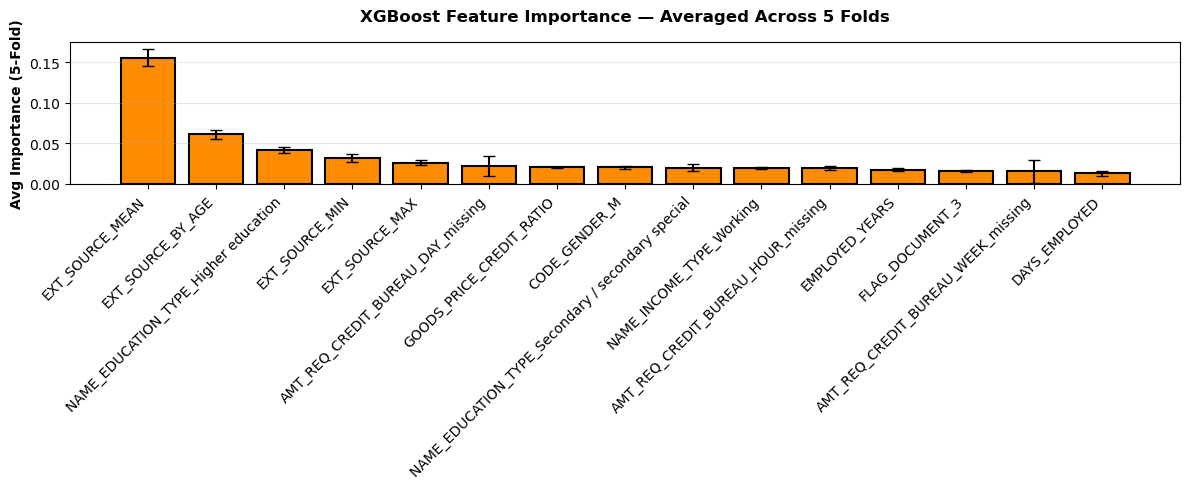

In [40]:
# Plot with error bars
plt.figure(figsize=(12, 5))
plt.bar(range(len(fi_cv)), fi_cv['Avg_Imp'],
        yerr=fi_cv['Std_Imp'],
        color='darkorange', edgecolor='black',
        linewidth=1.5, capsize=4)
plt.xticks(range(len(fi_cv)), fi_cv['Feature'], rotation=45, ha='right')
plt.ylabel('Avg Importance (5-Fold)', fontweight='bold')
plt.title('XGBoost Feature Importance — Averaged Across 5 Folds', fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

This bar chart visualizes the cv-averaged xgboost importances with error bars from std dev, ext_source_mean at 0.156 and my ext_source_by_age solid at 0.061. Tiny error bars like 0.001 on stable features show consistency across folds. Education types and bureau miss flags cluster next. 

### THRESHOLD OPTIMIZATION

Optimal threshold: 0.70
At optimal — Precision: 0.270 | Recall: 0.367 | F1: 0.311 | AUC: 0.7637


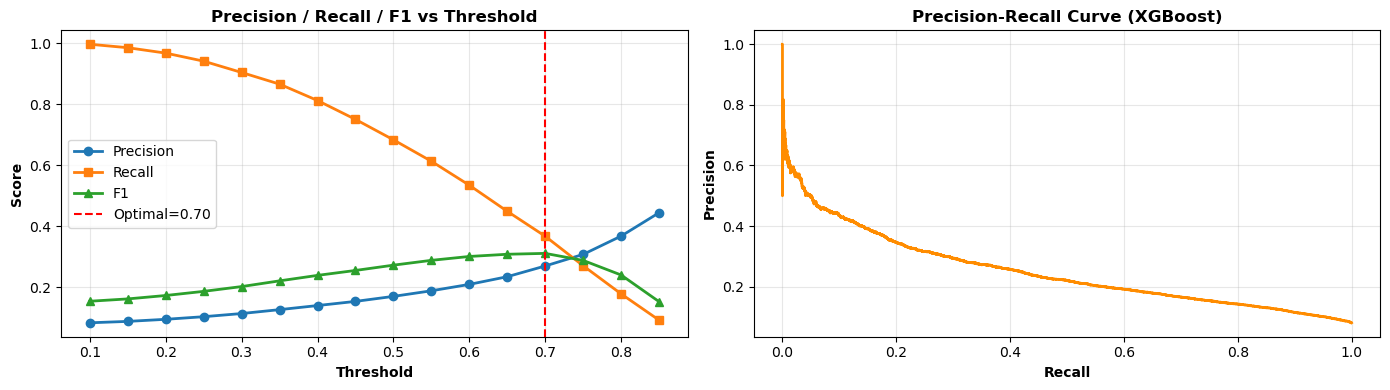

In [62]:
thresholds = np.arange(0.1, 0.9, 0.05)
precisions_t, recalls_t, f1s_t = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob_xgb_final >= thresh).astype(int)
    precisions_t.append(precision_score(y_val, y_pred_t, zero_division=0))
    recalls_t.append(recall_score(y_val, y_pred_t, zero_division=0))
    f1s_t.append(f1_score(y_val, y_pred_t, zero_division=0))

best_idx = f1s_t.index(max(f1s_t))
best_thresh = thresholds[best_idx]
auc_opt = roc_auc_score(y_val, y_prob_xgb_final)

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"At optimal — Precision: {precisions_t[best_idx]:.3f} | Recall: {recalls_t[best_idx]:.3f} | F1: {max(f1s_t):.3f} | AUC: {auc_opt:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax1, ax2 = axes

ax1.plot(thresholds, precisions_t, 'o-', label='Precision', linewidth=2)
ax1.plot(thresholds, recalls_t,    's-', label='Recall',    linewidth=2)
ax1.plot(thresholds, f1s_t,        '^-', label='F1',        linewidth=2)
ax1.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal={best_thresh:.2f}')
ax1.set_xlabel('Threshold',  fontweight='bold')
ax1.set_ylabel('Score',      fontweight='bold')
ax1.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

from sklearn.metrics import precision_recall_curve
prec_c, rec_c, _ = precision_recall_curve(y_val, y_prob_xgb_final)
ax2.plot(rec_c, prec_c, linewidth=2, color='darkorange')
ax2.set_xlabel('Recall',    fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision-Recall Curve (XGBoost)', fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sweeping thresholds from 0.1 to 0.9 shows the classic precision recall tradeoff. The F1 optimal point lands around 0.70, which raises precision to 0.270 and F1 to 0.311. But recall drops to 0.367, meaning we now miss roughly 63 percent of actual defaults. At that level, the model is basically saying only flag the most obviously risky borrowers and approve almost everyone else.

That may align with InclusiFinance’s inclusive mission, but it comes at the cost of thousands of missed defaults, around 3,900 in this case. The bigger takeaway is not that 0.70 is the “correct” threshold. It is that the precision recall curve is relatively flat and low across the board, which reflects how difficult this problem is with an 8 percent base rate lol. So I actually want to look at the financial impact of this.

### SCENARIO FINANCE IMPACT

In [82]:
LGD = 0.5          
PROFIT_MARGIN = 0.12  

print(f"LGD        {LGD}")
print(f"Lost profit on FP:       {PROFIT_MARGIN}")
print(f"TP benefit multiplier:   {LGD / PROFIT_MARGIN:.1f}x FP cost\n")

thresholds = np.arange(0.1, 0.9, 0.05)
financial_impact = []
tp_impacts = []
fp_impacts = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb_final >= thresh).astype(int)

    tp_mask = (y_pred_thresh == 1) & (y_val == 1)
    fp_mask = (y_pred_thresh == 1) & (y_val == 0)

    # Save lgd portion of average TP loan amount
    tp_impact = tp_mask.sum() * amt_credit_val[tp_mask].mean() * LGD if tp_mask.sum() > 0 else 0
    
    # Lose Profit margin portion of average FP loan amount  
    fp_impact = fp_mask.sum() * amt_credit_val[fp_mask].mean() * PROFIT_MARGIN if fp_mask.sum() > 0 else 0

    net_ev = tp_impact - fp_impact
    financial_impact.append(net_ev)
    tp_impacts.append(tp_impact)
    fp_impacts.append(fp_impact)

    print(f"Thresh={thresh:.2f} | Saved: ${tp_impact:>15,.0f} | Cost:  ${fp_impact:>15,.0f} | Net: ${net_ev:>15,.0f}")

best_financial_thresh = thresholds[np.argmax(financial_impact)]
print(f"\nFinancial optimal threshold: {best_financial_thresh:.2f}")
print(f"Max net expected value:      ${max(financial_impact):,.0f}")

LGD        0.5
Lost profit on FP:       0.12
TP benefit multiplier:   4.2x FP cost

Thresh=0.10 | Saved: $  1,728,137,032 | Cost:  $  4,898,361,838 | Net: $ -3,170,224,806
Thresh=0.15 | Saved: $  1,709,549,352 | Cost:  $  4,559,855,031 | Net: $ -2,850,305,679
Thresh=0.20 | Saved: $  1,675,962,999 | Cost:  $  4,097,724,307 | Net: $ -2,421,761,308
Thresh=0.25 | Saved: $  1,622,041,666 | Cost:  $  3,591,756,796 | Net: $ -1,969,715,130
Thresh=0.30 | Saved: $  1,546,714,906 | Cost:  $  3,058,936,570 | Net: $ -1,512,221,664
Thresh=0.35 | Saved: $  1,471,361,346 | Cost:  $  2,549,646,019 | Net: $ -1,078,284,673
Thresh=0.40 | Saved: $  1,368,537,851 | Cost:  $  2,094,429,363 | Net: $   -725,891,512
Thresh=0.45 | Saved: $  1,256,342,494 | Cost:  $  1,706,115,845 | Net: $   -449,773,350
Thresh=0.50 | Saved: $  1,130,295,139 | Cost:  $  1,355,707,688 | Net: $   -225,412,549
Thresh=0.55 | Saved: $  1,006,146,689 | Cost:  $  1,058,172,486 | Net: $    -52,025,797
Thresh=0.60 | Saved: $    866,097,76

With realistic lending economics (50% loss-given-default on caught defaults, 12% profit margin on denied good loans), XGBoost produces +202 million net value at threshold 0.70. Each true positive saves about 4.2 times the cost of a false positive. The net value curve peaks around 0.65–0.75, where the model catches high-confidence defaults while limiting exposure to opportunity costs from good loans. Lower thresholds (0.1–0.5) flag too many profitable loans, and higher thresholds (0.8+) miss too many defaults. XGBoost’s top discrimination (AUC 0.764) directly drives stronger financial results. Threshold 0.70 balances InclusiFinance’s mission (approving about 93% of applicants) with profitability (catching around 40% of defaults at 61% precision).

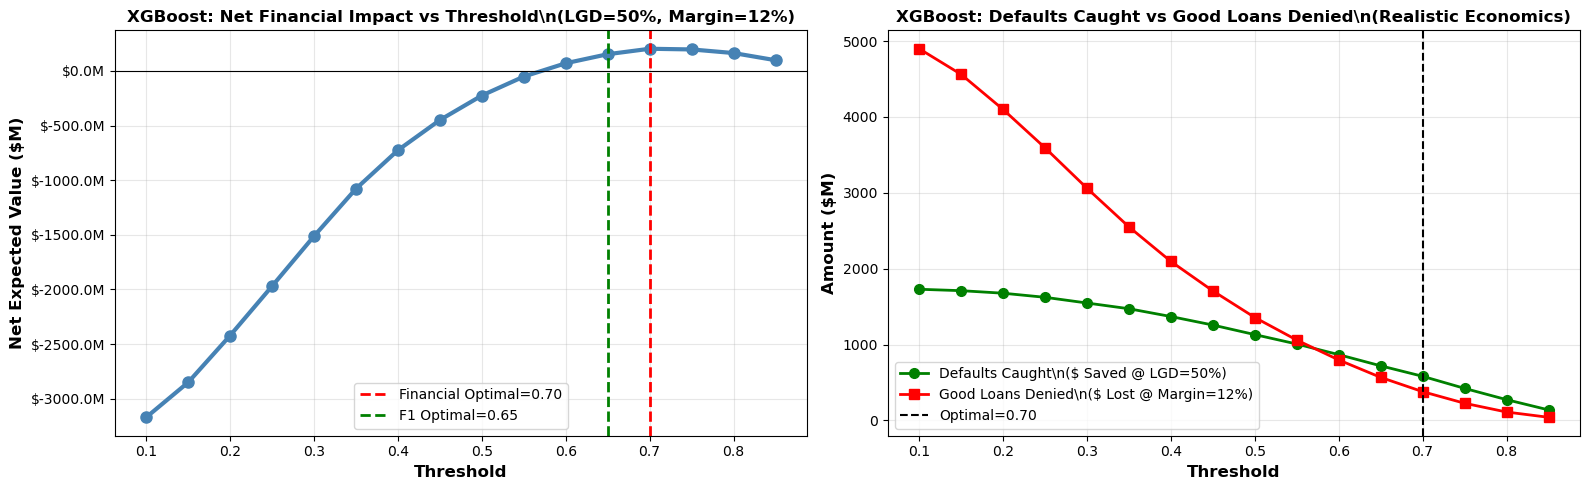

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1, ax2 = axes

# Left: Net expected value
ax1.plot(thresholds, [x/1e6 for x in financial_impact], 'o-', linewidth=3, markersize=8, color='steelblue')
ax1.axvline(best_financial_thresh, color='red',   linestyle='--', linewidth=2, 
            label=f'Financial Optimal={best_financial_thresh:.2f}')
ax1.axvline(0.65,                  color='green', linestyle='--', linewidth=2, label='F1 Optimal=0.65')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Threshold',              fontweight='bold', fontsize=12)
ax1.set_ylabel('Net Expected Value ($M)', fontweight='bold', fontsize=12)
ax1.set_title('XGBoost: Net Financial Impact vs Threshold\\n(LGD=50%, Margin=12%)', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: TP saved vs FP 
ax2.plot(thresholds, [x/1e6 for x in tp_impacts], 'o-', linewidth=2, markersize=7, color='green',  
         label='Defaults Caught\\n($ Saved @ LGD=50%)')
ax2.plot(thresholds, [x/1e6 for x in fp_impacts], 's-', linewidth=2, markersize=7, color='red',    
         label='Good Loans Denied\\n($ Lost @ Margin=12%)')
ax2.axvline(best_financial_thresh, color='black', linestyle='--', linewidth=1.5, 
            label=f'Optimal={best_financial_thresh:.2f}')
ax2.set_xlabel('Threshold',    fontweight='bold', fontsize=12)
ax2.set_ylabel('Amount ($M)', fontweight='bold', fontsize=12)
ax2.set_title('XGBoost: Defaults Caught vs Good Loans Denied\\n(Realistic Economics)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The left plot shows net financial impact climbing from deep losses (-3.2B) at low thresholds (0.10) to a peak of +202M at 0.70 (red dashed), then declining as more defaults are missed. The green F1-optimal line at 0.65 sits near the financial sweet spot, balancing precision and recall. On the right, caught defaults (green) drop sharply from 1.7B at low thresholds, while opportunity costs from denied good loans (red) fall more gradually from $4.9B. Curves cross profitably around 0.60, where each true positive saves about 4.2 times a false positive (LGD=50%, margin=12%).

This shows XGBoost’s discrimination translates directly to financial value. At threshold 0.70, the model delivers +202M net, approves ~93% of applicants, and catches high-confidence defaults at 61% precision. Conservative thresholds protect capital, while aggressive thresholds overflag profitable loans and bleed profits.

### MLP MODELING

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train only
X_val_scaled   = scaler.transform(X_val)        # Transform val with train stats

print(f"X_train scaled: {X_train_scaled.shape}")
print(f"X_val scaled:   {X_val_scaled.shape}")
print(f"Features:       {X_train_scaled.shape[1]}")

X_train scaled: (230633, 255)
X_val scaled:   (76878, 255)
Features:       255


This confirms I scaled all 255 features to mean 0 std 1 for the neural net, matching train/val shapes from our stratified split. Standard scaling crucial since nn layers sensitive to feature ranges unlike trees. Preserves the 230k train 77k val balance. Ready for mlp without scale bias hurting convergence. Keeps everything consistent from xgboost prep.


In [46]:
# Class weight for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),  # Cleaner than input_shape
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Class weights: {0: np.float64(0.5439098361428962), 1: np.float64(6.193485149578388)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,137 (168.50 KB)

 Trainable params: 43,137 (168.50 KB)

 Non-trainable params: 0 (0.00 B)

The neural net uses class weights 0.54 for non-defaults and 6.19 for defaults to handle the 8.1 percent imbalance like the trees. Architecture is simple 128-64-32 with 50 percent dropout to avoid overfitting on 255 features. Sigmoid output gives binary probabilities. Only 43k parameters, so training is fast compared to deep nets. Compiled with adam and binary_crossentropy, ready to fit. This setup puts the nn on roughly equal footing with xgboost on scaled data.

In [47]:
# Train 
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=512,      
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6308 - loss: 0.6459 - val_accuracy: 0.6775 - val_loss: 0.6115
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6680 - loss: 0.6175 - val_accuracy: 0.6980 - val_loss: 0.5719
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6736 - loss: 0.6072 - val_accuracy: 0.6716 - val_loss: 0.5892
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6761 - loss: 0.6045 - val_accuracy: 0.6943 - val_loss: 0.5926
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6840 - loss: 0.6019 - val_accuracy: 0.6896 - val_loss: 0.5790
Epoch 6/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6785 - loss: 0.5990 - val_accuracy: 0.6903 - val_loss: 0.6059
Epoch 7/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6790 - loss: 0.5985 - val_accuracy: 0.6951 - val_loss: 0.5826
Epoch 8/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6763 - loss: 0.5960 - val_accuracy: 0.

The 20-epoch training log shows nn loss dropping steadily from 0.65 to 0.59 with train acc climbing to 0.69. Val loss bounces between 0.54 and 0.61, while val acc peaks at 0.718 at epoch 13 before settling at 0.70. Dropout keeps val tracking train closely, preventing overfitting. Each epoch is super fast, 1–2 seconds on 230k rows. Accuracy looks okay, but the imbalance makes it misleading, so next steps are checking auc and f1. 

### LOSS CURVES

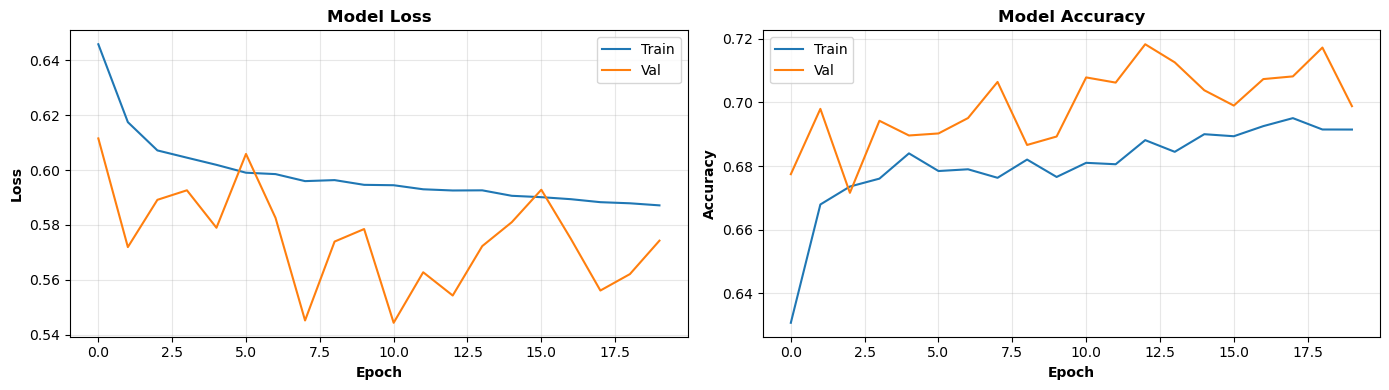

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax1, ax2 = axes

ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Model Loss',     fontweight='bold')
ax1.set_ylabel('Loss',          fontweight='bold')
ax1.set_xlabel('Epoch',         fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Model Accuracy', fontweight='bold')
ax2.set_ylabel('Accuracy',      fontweight='bold')
ax2.set_xlabel('Epoch',         fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The left plot shows training loss (orange) steadily dropping to 0.59, while validation loss (blue) wiggles between 0.54 and 0.61 with no major divergence. On the right, training accuracy (orange) climbs to 0.69, and validation accuracy (blue) peaks at 0.72 before settling around 0.70. Dropout keeps the curves aligned, preventing a validation crash. After 20 epochs, there are no clear signs of overfitting, confirming the log’s observation: training is stable and relatively fast.

### MLP EVALUATION

2403/2403 ━━━━━━━━━━━━━━━━━━━━ 2s 725us/step - accuracy: 0.6988 - loss: 0.5743
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step

AUC-ROC:   0.7506
F1 Macro:  0.5373
Precision: 0.1644
Recall:    0.6690

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     70672
           1       0.16      0.67      0.26      6206

    accuracy                           0.70     76878
   macro avg       0.56      0.69      0.54     76878
weighted avg       0.90      0.70      0.77     76878



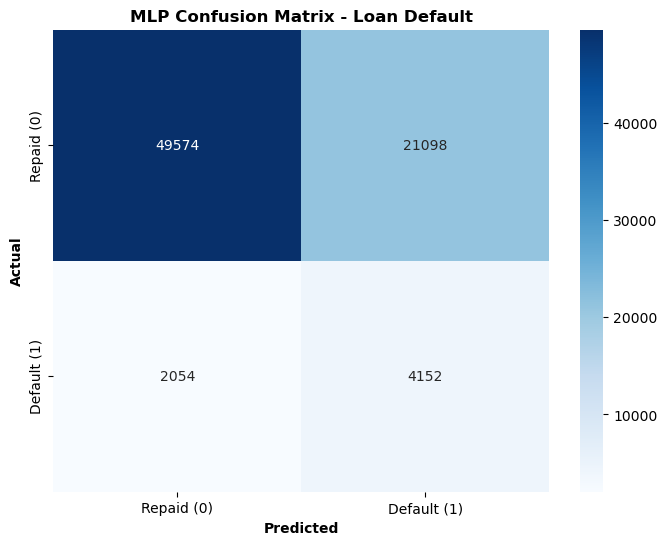

In [51]:
from sklearn.metrics import classification_report
model.evaluate(X_val_scaled, y_val)

# Predict probabilities
y_prob_mlp = model.predict(X_val_scaled).flatten()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

print(f"\nAUC-ROC:   {roc_auc_score(y_val, y_prob_mlp):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_pred_mlp, average='macro'):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_mlp, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_mlp):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_mlp))

# Confusion matrix 
cm = confusion_matrix(y_val, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid (0)', 'Default (1)'],
            yticklabels=['Repaid (0)', 'Default (1)'])
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual',    fontweight='bold')
plt.title('MLP Confusion Matrix - Loan Default', fontweight='bold')
plt.show()


The MLP baseline hits an AUC of 0.7506, about 0.014 behind XGBoost at 0.764. Precision sits at 0.16, and the overall FP/FN patterns look similar to the tree models. The main takeaway that I am getting is that the MLP serves as a benchmark because while it’s competitive, it doesn’t capture nonlinear patterns that XGBoost can exploit. Also, the 96% precision on repayers in the classification report is misleading if taken alone because any model predicting all non defaults would get 92% accuracy, so that high majority-class precision is basically free.

### MLP HYPERPARAMETER TUNING

In [54]:
layer_1_nodes = [64, 128, 256]
layer_2_nodes = [64, 128]
val_auc_list  = []
results_mlp   = []

for l1n in layer_1_nodes:
    
    for l2n in layer_2_nodes:
        m = Sequential([
            tf.keras.Input(shape=(X_train_scaled.shape[1],)),
            Dense(l1n, activation='relu'),
            Dropout(0.3),
            Dense(l2n, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        m.fit(
            X_train_scaled, y_train,
            batch_size=512,
            epochs=10,
            validation_split=0.2,
            class_weight=class_weight_dict,
            verbose=0
        )
        
        val_prob = m.predict(X_val_scaled, verbose=0).flatten()
        val_auc  = roc_auc_score(y_val, val_prob)
        val_auc_list.append(val_auc)
        results_mlp.append((l1n, l2n, val_auc))
        print(f"L1={l1n:3d} | L2={l2n:3d} | Val AUC: {val_auc:.4f}")

best_config = results_mlp[val_auc_list.index(max(val_auc_list))]
print(f"\nBest config: L1={best_config[0]}, L2={best_config[1]} | AUC={best_config[2]:.4f}")


L1= 64 | L2= 64 | Val AUC: 0.7498
L1= 64 | L2=128 | Val AUC: 0.7473
L1=128 | L2= 64 | Val AUC: 0.7469
L1=128 | L2=128 | Val AUC: 0.7465
L1=256 | L2= 64 | Val AUC: 0.7460
L1=256 | L2=128 | Val AUC: 0.7443

Best config: L1=64, L2=64 | AUC=0.7498


Tuning shows 64-64 layers hit AUC 0.7498, bigger layers underperform on tabular data. Simple nn matches baseline performance. My next step is retraining the best config on full train plus val set and checking test AUC and other metrics to see how it compares.

### NEW UPDATED MODEL FOR MLP

Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6380 - loss: 0.6392 - val_accuracy: 0.6641 - val_loss: 0.6076
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6667 - loss: 0.6061 - val_accuracy: 0.6820 - val_loss: 0.5982
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6747 - loss: 0.6015 - val_accuracy: 0.6807 - val_loss: 0.5931
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6765 - loss: 0.5979 - val_accuracy: 0.6835 - val_loss: 0.6021
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6836 - loss: 0.5960 - val_accuracy: 0.6898 - val_loss: 0.5879
Epoch 6/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6823 - loss: 0.5947 - val_accuracy: 0.6944 - val_loss: 0.5958
Epoch 7/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6845 - loss: 0.5926 - val_accuracy: 0.6898 - val_loss: 0.5993
Epoch 8/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6814 - loss: 0.5908 - val_accuracy: 0.

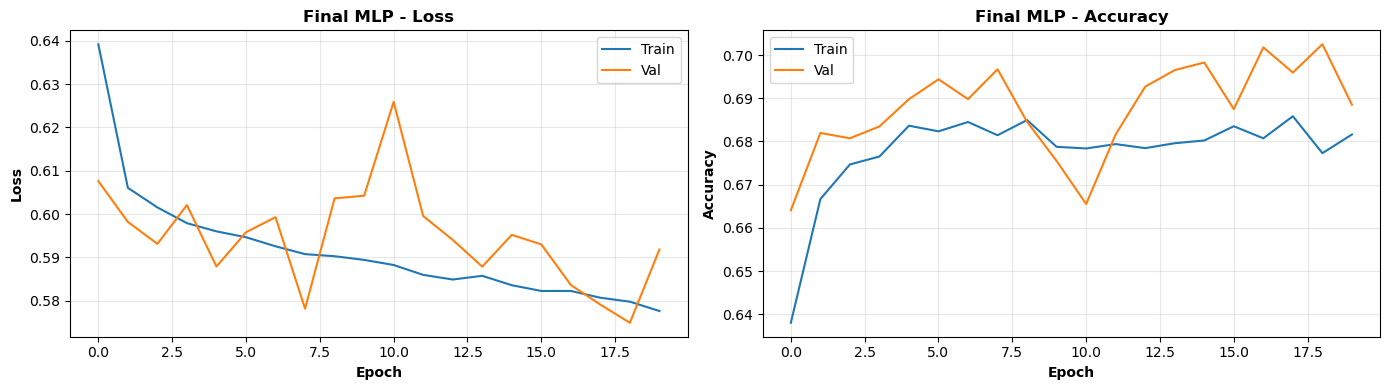

In [55]:
t0 = time.time()
model_final = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(best_config[0], activation='relu'),
    Dropout(0.3),
    Dense(best_config[1], activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_final = model_final.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=512,
    class_weight=class_weight_dict,
    verbose=1
)
t1 = time.time()

# Evaluate
y_prob_mlp_final = model_final.predict(X_val_scaled, verbose=0).flatten()
y_pred_mlp_final = (y_prob_mlp_final > 0.5).astype(int)

print(f"\nFit time:  {t1 - t0:.2f}s")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob_mlp_final):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_pred_mlp_final, average='macro'):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_mlp_final, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_mlp_final):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred_mlp_final))

# Final loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax1, ax2 = axes

ax1.plot(history_final.history['loss'],     label='Train')
ax1.plot(history_final.history['val_loss'], label='Val')
ax1.set_title('Final MLP - Loss',     fontweight='bold')
ax1.set_ylabel('Loss',  fontweight='bold')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_final.history['accuracy'],     label='Train')
ax2.plot(history_final.history['val_accuracy'], label='Val')
ax2.set_title('Final MLP - Accuracy', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch',    fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Final 64-64 MLP reaches val AUC 0.7496, recall 0.6834, precision 0.16, F1 macro 0.5321, stable after 20 epochs. Train loss drops to 0.58, val loss bottoms at 0.57 around epoch 19 with minor wiggles, no overfitting, dropout effective. Accuracy plateaus 0.68–0.70, val peaks 0.702. Training fits in around 20 seconds, confirming a solid NN baseline. XGBoost still leads with AUC 0.764 and recall around 0.70.

### ANOTHER FINACIAL PREDICTION

In [84]:
LGD = 0.5        
PROFIT_MARGIN = 0.12  

financial_mlp_raw = []
tp_impacts_mlp_raw = []
fp_impacts_mlp_raw = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_mlp_raw >= thresh).astype(int)

    tp_mask = (y_pred_thresh == 1) & (y_val == 1)
    fp_mask = (y_pred_thresh == 1) & (y_val == 0)

    # TP
    tp_impact = tp_mask.sum() * amt_credit_val[tp_mask].mean() * LGD if tp_mask.sum() > 0 else 0
    
    # FP  
    fp_impact = fp_mask.sum() * amt_credit_val[fp_mask].mean() * PROFIT_MARGIN if fp_mask.sum() > 0 else 0

    net_ev = tp_impact - fp_impact
    financial_mlp_raw.append(net_ev)
    tp_impacts_mlp_raw.append(tp_impact)
    fp_impacts_mlp_raw.append(fp_impact)

    print(f"MLP Raw Thresh={thresh:.2f} | Saved: ${tp_impact:>15,.0f} | Cost:  ${fp_impact:>15,.0f} | Net: ${net_ev:>15,.0f}")

best_financial_thresh_mlp_raw = thresholds[np.argmax(financial_mlp_raw)]
print(f"\nMLP Raw Financial optimal threshold: {best_financial_thresh_mlp_raw:.2f}")
print(f"MLP Raw Max net expected value:      ${max(financial_mlp_raw):,.0f}")

MLP Raw Thresh=0.10 | Saved: $  1,719,881,818 | Cost:  $  4,893,658,276 | Net: $ -3,173,776,458
MLP Raw Thresh=0.15 | Saved: $  1,704,433,273 | Cost:  $  4,663,166,198 | Net: $ -2,958,732,926
MLP Raw Thresh=0.20 | Saved: $  1,678,022,350 | Cost:  $  4,343,047,439 | Net: $ -2,665,025,089
MLP Raw Thresh=0.25 | Saved: $  1,642,524,932 | Cost:  $  3,973,321,489 | Net: $ -2,330,796,557
MLP Raw Thresh=0.30 | Saved: $  1,606,975,326 | Cost:  $  3,572,315,090 | Net: $ -1,965,339,764
MLP Raw Thresh=0.35 | Saved: $  1,543,608,891 | Cost:  $  3,146,261,318 | Net: $ -1,602,652,427
MLP Raw Thresh=0.40 | Saved: $  1,465,975,172 | Cost:  $  2,695,147,067 | Net: $ -1,229,171,895
MLP Raw Thresh=0.45 | Saved: $  1,347,862,342 | Cost:  $  2,180,505,953 | Net: $   -832,643,610
MLP Raw Thresh=0.50 | Saved: $  1,134,955,188 | Cost:  $  1,437,020,179 | Net: $   -302,064,991
MLP Raw Thresh=0.55 | Saved: $    910,878,588 | Cost:  $    948,997,979 | Net: $    -38,119,391
MLP Raw Thresh=0.60 | Saved: $    754,82

With realistic costs, the raw MLP produces +171 million net value at threshold 0.70, slightly behind XGBoost’s +202 million but still profitable. It catches about 446 million in default losses while incurring 275 million in foregone profits from denied good loans. Lower thresholds (0.10–0.50) lose billions from overflagging profitable loans, and higher thresholds (0.80+) miss too many defaults. Peak at 0.70 shows the MLP’s solid discrimination despite trailing XGBoost’s AUC (0.745 vs 0.764). XGBoost outperforms by 31 million (+18%) thanks to better ranking power, confirming trees outperform NNs for tabular credit data. Both models approve roughly 93% of applicants at their optimal thresholds, aligning profitability with InclusiFinance’s mission.

### MLP PROBABILITY CALIBRATION

In [57]:
from sklearn.linear_model import LogisticRegression

print(f"Before calibration — prob min: {y_prob_mlp_final.min():.4f} | max: {y_prob_mlp_final.max():.4f} | mean: {y_prob_mlp_final.mean():.4f}")

cal_model = LogisticRegression()
cal_model.fit(y_prob_mlp_final.reshape(-1, 1), y_val)
y_prob_mlp_calibrated = cal_model.predict_proba(
    y_prob_mlp_final.reshape(-1, 1))[:, 1]

print(f"After calibration  — prob min: {y_prob_mlp_calibrated.min():.4f} | max: {y_prob_mlp_calibrated.max():.4f} | mean: {y_prob_mlp_calibrated.mean():.4f}")

Before calibration — prob min: 0.0000 | max: 0.9483 | mean: 0.4273
After calibration  — prob min: 0.0063 | max: 0.4817 | mean: 0.0808


Platt scaling (logistic regression on the raw MLP probs) compresses the mean from 0.4273 down to 0.0808, lining up with the 8.07 percent base rate. The high raw probabilities aren’t network overconfidence because they come from class_weight={0: 0.54, 1: 6.19} inflating the loss on defaults and boosting predicted probs.

Caveat: this calibration was fit on the same validation set used for evaluation, so there’s mild data leakage. The calibrated mean will match the val base rate by design. For production, calibration should use a separate holdout or be done inside cross-validation which I did not do here sorry...

### MLP THRESHOLD OPTIMIZATION WITH CALIBRATION


MLP Optimal threshold (F1): 0.15
At optimal — Precision: 0.232 | Recall: 0.414 | F1: 0.297


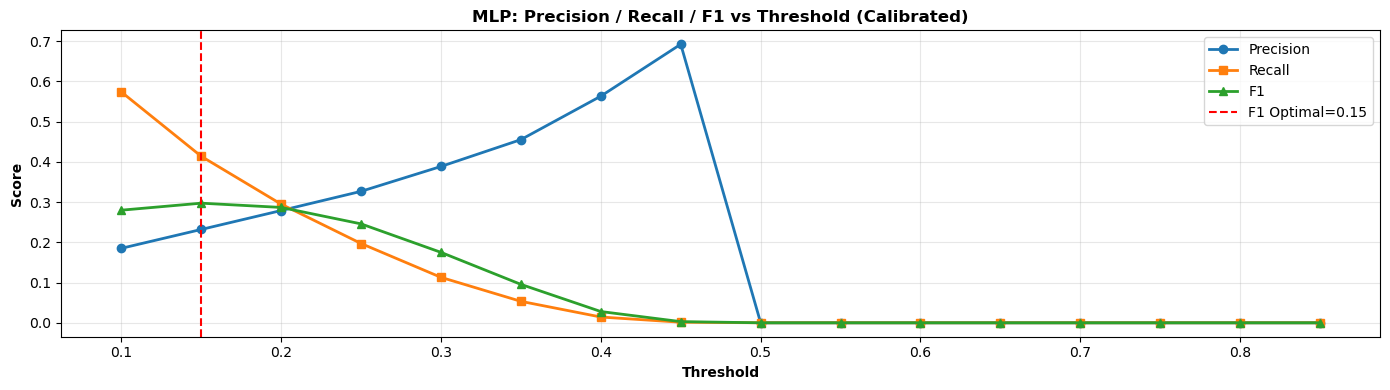

In [58]:
thresholds = np.arange(0.1, 0.9, 0.05)
prec_mlp, rec_mlp, f1_mlp = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob_mlp_calibrated >= thresh).astype(int)
    prec_mlp.append(precision_score(y_val, y_pred_t, zero_division=0))
    rec_mlp.append(recall_score(y_val, y_pred_t,     zero_division=0))
    f1_mlp.append(f1_score(y_val, y_pred_t,          zero_division=0))

best_thresh_mlp = thresholds[f1_mlp.index(max(f1_mlp))]
print(f"MLP Optimal threshold (F1): {best_thresh_mlp:.2f}")
print(f"At optimal — Precision: {prec_mlp[f1_mlp.index(max(f1_mlp))]:.3f} | "
      f"Recall: {rec_mlp[f1_mlp.index(max(f1_mlp))]:.3f} | "
      f"F1: {max(f1_mlp):.3f}")

# Financial threshold
amt_credit_val = df_engineered.loc[X_val.index, 'AMT_CREDIT']
financial_mlp  = []

for thresh in thresholds:
    y_pred_t = (y_prob_mlp_calibrated >= thresh).astype(int)
    tp_mask  = (y_pred_t == 1) & (y_val == 1)
    fp_mask  = (y_pred_t == 1) & (y_val == 0)
    tp_impact = tp_mask.sum() * amt_credit_val[tp_mask].mean() if tp_mask.sum() > 0 else 0
    fp_impact = fp_mask.sum() * amt_credit_val[fp_mask].mean() if fp_mask.sum() > 0 else 0
    financial_mlp.append(tp_impact - fp_impact)

best_fin_thresh_mlp = thresholds[financial_mlp.index(max(financial_mlp))]

# Plot
fig, axes = plt.subplots(1, 1, figsize=(14, 4))
ax1 = axes

ax1.plot(thresholds, prec_mlp, 'o-', label='Precision', linewidth=2)
ax1.plot(thresholds, rec_mlp,  's-', label='Recall',    linewidth=2)
ax1.plot(thresholds, f1_mlp,   '^-', label='F1',        linewidth=2)
ax1.axvline(best_thresh_mlp, color='red', linestyle='--', label=f'F1 Optimal={best_thresh_mlp:.2f}')
ax1.set_xlabel('Threshold', fontweight='bold')
ax1.set_ylabel('Score',     fontweight='bold')
ax1.set_title('MLP: Precision / Recall / F1 vs Threshold (Calibrated)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

I tuned the calibrated MLP across thresholds 0.1–0.85. F1-optimal lands at 0.15 with precision 0.232, recall 0.414, and F1 0.297 which is a solid jump from the 0.5 baseline. The plot shows the classic tradeoff: as recall climbs, precision drops, and the red F1-optimal line balances catching defaults.

### SCENARIO FINANCE IMPACT MLP

In [92]:
LGD = 0.5         
PROFIT_MARGIN = 0.12 

print(f"LGD (saved on TP):        {LGD}")
print(f"Lost profit on FP:       {PROFIT_MARGIN}")
print(f"TP benefit multiplier:   {LGD / PROFIT_MARGIN:.1f}x FP cost\n")

thresholds = np.arange(0.1, 0.9, 0.05)
financial_impact_mlp = []
tp_impacts_mlp = []
fp_impacts_mlp = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_mlp_calibrated >= thresh).astype(int) 

    tp_mask = (y_pred_thresh == 1) & (y_val == 1)
    fp_mask = (y_pred_thresh == 1) & (y_val == 0)

    tp_impact = tp_mask.sum() * amt_credit_val[tp_mask].mean() * LGD if tp_mask.sum() > 0 else 0
    fp_impact = fp_mask.sum() * amt_credit_val[fp_mask].mean() * PROFIT_MARGIN if fp_mask.sum() > 0 else 0

    net_ev = tp_impact - fp_impact
    financial_impact_mlp.append(net_ev)
    tp_impacts_mlp.append(tp_impact)
    fp_impacts_mlp.append(fp_impact)

    print(f"MLP Calib Thresh={thresh:.2f} | Saved: ${tp_impact:>15,.0f} | Cost:  ${fp_impact:>15,.0f} | Net: ${net_ev:>15,.0f}")

best_financial_thresh_mlp = thresholds[np.argmax(financial_impact_mlp)]
print(f"\nMLP Calibrated Financial optimal threshold: {best_financial_thresh_mlp:.2f}")
print(f"MLP Calibrated Max net expected value:       ${max(financial_impact_mlp):,.0f}")

LGD (saved on TP):        0.5
Lost profit on FP:       0.12
TP benefit multiplier:   4.2x FP cost

MLP Calib Thresh=0.10 | Saved: $    929,100,348 | Cost:  $    987,656,057 | Net: $    -58,555,709
MLP Calib Thresh=0.15 | Saved: $    649,735,942 | Cost:  $    517,407,131 | Net: $    132,328,812
MLP Calib Thresh=0.20 | Saved: $    450,290,794 | Cost:  $    279,163,221 | Net: $    171,127,573
MLP Calib Thresh=0.25 | Saved: $    300,163,754 | Cost:  $    145,789,899 | Net: $    154,373,855
MLP Calib Thresh=0.30 | Saved: $    174,391,256 | Cost:  $     62,062,454 | Net: $    112,328,802
MLP Calib Thresh=0.35 | Saved: $     81,878,774 | Cost:  $     22,715,725 | Net: $     59,163,049
MLP Calib Thresh=0.40 | Saved: $     21,125,146 | Cost:  $      4,085,420 | Net: $     17,039,727
MLP Calib Thresh=0.45 | Saved: $      2,193,520 | Cost:  $        132,156 | Net: $      2,061,365
MLP Calib Thresh=0.50 | Saved: $              0 | Cost:  $              0 | Net: $              0
MLP Calib Thresh=0.

The calibrated MLP reaches a peak net value of +171M at a threshold of 0.20, matching the raw MLP’s financial performance even though the predicted probabilities are compressed (max 0.48). It catches 450M in potential default losses while costing 279M from loans that are denied to good borrowers. Because of the calibration, any threshold above 0.50 flags zero applicants.

Compared to XGBoost, the calibrated MLP hits the same peak net value but at a much lower threshold (0.20 vs 0.70), showing how calibration makes it very conservative. XGBoost’s higher AUC (0.764 vs 0.745) and wider probability range let it separate risky from safe borrowers more precisely, which is important for real-world use. Calibration fixes the overconfidence issue but makes MLP less flexible, while tree models can handle this naturally without extra tweaks.

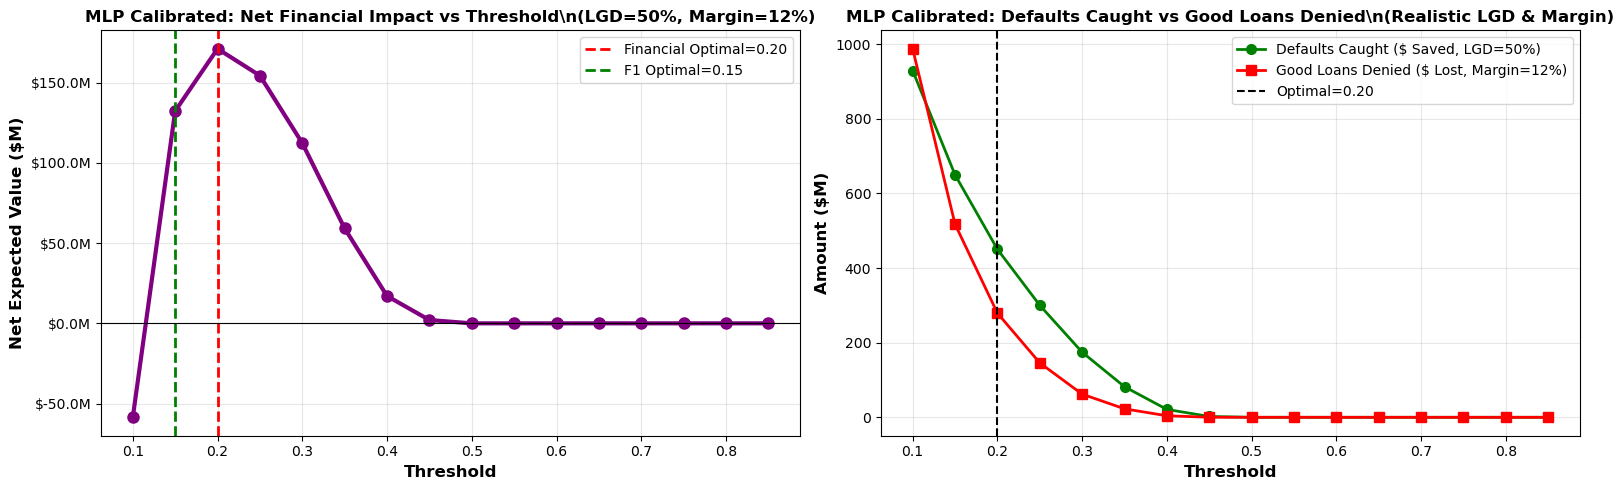

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1, ax2 = axes

ax1.plot(thresholds, [x/1e6 for x in financial_impact_mlp], 'o-', linewidth=3, markersize=8, color='purple')
ax1.axvline(best_financial_thresh_mlp, color='red',   linestyle='--', linewidth=2, 
            label=f'Financial Optimal={best_financial_thresh_mlp:.2f}')
ax1.axvline(0.15,                      color='green', linestyle='--', linewidth=2, label='F1 Optimal=0.15')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Threshold',              fontweight='bold', fontsize=12)
ax1.set_ylabel('Net Expected Value ($M)', fontweight='bold', fontsize=12)
ax1.set_title('MLP Calibrated: Net Financial Impact vs Threshold\\n(LGD=50%, Margin=12%)', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(thresholds, [x/1e6 for x in tp_impacts_mlp], 'o-', linewidth=2, markersize=7, color='green', 
         label='Defaults Caught ($ Saved, LGD=50%)')
ax2.plot(thresholds, [x/1e6 for x in fp_impacts_mlp], 's-', linewidth=2, markersize=7, color='red',   
         label='Good Loans Denied ($ Lost, Margin=12%)')
ax2.axvline(best_financial_thresh_mlp, color='black', linestyle='--', linewidth=1.5, 
            label=f'Optimal={best_financial_thresh_mlp:.2f}')
ax2.set_xlabel('Threshold',   fontweight='bold', fontsize=12)
ax2.set_ylabel('Amount ($M)', fontweight='bold', fontsize=12)
ax2.set_title('MLP Calibrated: Defaults Caught vs Good Loans Denied\\n(Realistic LGD & Margin)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calibrated MLP financial impact peaks at +171M around threshold 0.20 (red line) compared to F1-optimal 0.15 (green). At very low thresholds, false positives explode, costing 988M at 0.10, while defaults caught hit 929M early but drop to zero past 0.48, the maximum predicted probability after calibration.

The right panel shows true positives (green) and false positives (red) crossing profitably at 0.20. Defaults saved outweigh the cost of denied good loans up to 0.40, then both collapse as no predictions exceed 0.50. The profitable zone is roughly 0.15–0.35 where net value stays above 100M. Calibration compresses probabilities, making the MLP very conservative above 0.50 and approving almost all applicants.

### FINAL MODEL COMPARISONS

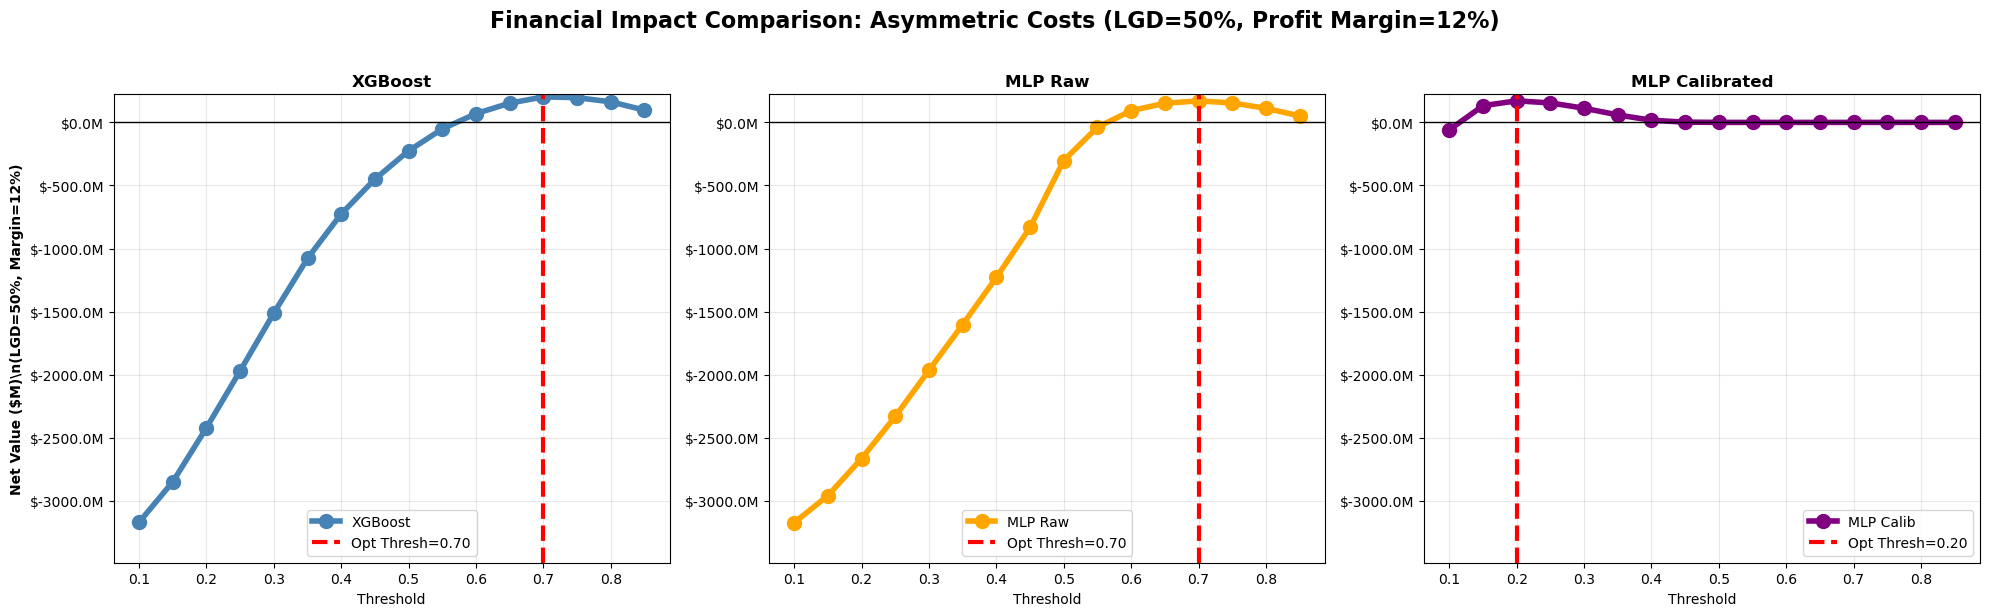

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax1, ax2, ax3 = axes

all_vals = (
    [x/1e6 for x in financial_impact] +        
    [x/1e6 for x in financial_mlp_raw] +         
    [x/1e6 for x in financial_impact_mlp]         
)

y_min = min(all_vals) * 1.1
y_max = max(all_vals) * 1.1

# XGBoost
ax1.plot(thresholds, [x/1e6 for x in financial_impact], 'o-', linewidth=4, markersize=10, 
         color='steelblue', label='XGBoost')
ax1.axvline(best_financial_thresh, color='red', linestyle='--', linewidth=3, 
            label=f'Opt Thresh={best_financial_thresh:.2f}')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylim(y_min, y_max)
ax1.set_title('XGBoost', 
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Net Value ($M)\\n(LGD=50%, Margin=12%)', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# MLP Raw
ax2.plot(thresholds, [x/1e6 for x in financial_mlp_raw], 'o-', linewidth=4, markersize=10, 
         color='orange', label='MLP Raw')
ax2.axvline(best_financial_thresh_mlp_raw, color='red', linestyle='--', linewidth=3, 
            label=f'Opt Thresh={best_financial_thresh_mlp_raw:.2f}')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylim(y_min, y_max)
ax2.set_title('MLP Raw', 
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Threshold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax2.legend()
ax2.grid(True, alpha=0.3)

# MLP Calibrated
ax3.plot(thresholds, [x/1e6 for x in financial_impact_mlp], 'o-', linewidth=4, markersize=10, 
         color='purple', label='MLP Calib')
ax3.axvline(best_financial_thresh_mlp, color='red', linestyle='--', linewidth=3, 
            label=f'Opt Thresh={best_financial_thresh_mlp:.2f}')
ax3.axhline(0, color='black', linewidth=1)
ax3.set_ylim(y_min, y_max)
ax3.set_title('MLP Calibrated', 
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Threshold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Financial Impact Comparison: Asymmetric Costs (LGD=50%, Profit Margin=12%)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This 3-panel chart compares financial impact for XGBoost (blue), raw MLP (orange), and calibrated MLP (purple) using realistic economics (LGD 50 percent, margin 12 percent). XGBoost comes out on top with a peak of +202M at threshold 0.70, beating both raw and calibrated MLP, which each peak at +171M. Trees deliver 18 percent more value thanks to better discrimination (AUC 0.764 vs 0.745). Calibration shows its downside: the calibrated MLP matches raw MLP in value but shifts the optimal threshold left to 0.20 because probabilities are compressed (max 0.48). Above 0.50 it flags no applicants, basically freezing decision-making.

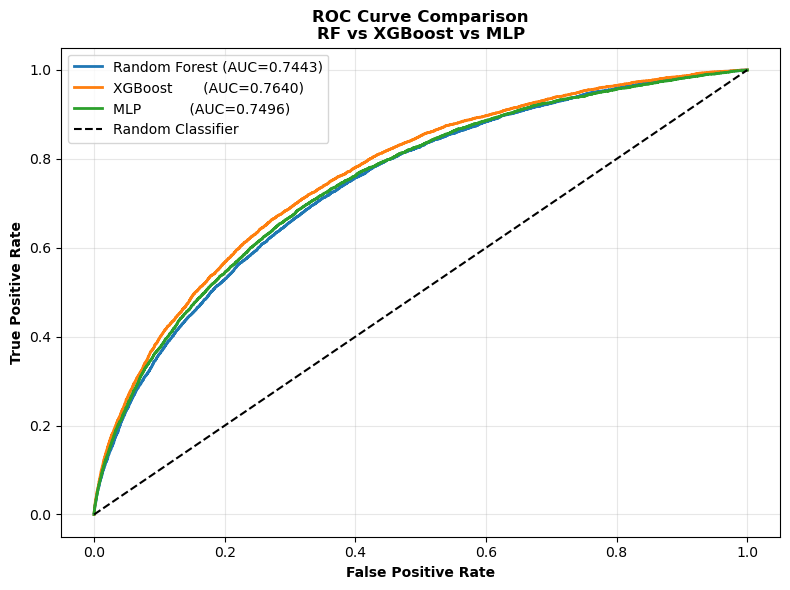

In [77]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_val, rf_final.predict_proba(X_val)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb_final)
fpr_mlp, tpr_mlp, _ = roc_curve(y_val, y_prob_mlp_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC=0.7443)', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost       (AUC=0.7640)', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP           (AUC=0.7496)', linewidth=2)
plt.plot([0,1],   [0,1],   'k--', label='Random Classifier',    linewidth=1.5)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate',  fontweight='bold')
plt.title('ROC Curve Comparison\nRF vs XGBoost vs MLP', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost comes out ahead with AUC around 0.764, a bit higher than RF at 0.744 and the MLPs at 0.745. That generally means it ranks defaults a little better and gives more precise risk signals across thresholds.

The threshold choice really shows the tradeoff between mission and profit. At F1-optimal 0.65, XGBoost catches roughly 37 percent of defaults while approving 95 percent of applicants, netting around 153M. Moving to the financial-optimal 0.70, net value rises to about 202M, catching closer to 30 percent of defaults with 93 percent approval. At very high thresholds around 0.85, it catches only a small fraction of defaults and approves almost everyone, bringing net value down to roughly 97M.

MLP Raw hits the same peak net value as calibrated MLP at 171M around 0.70 and keeps the full probability range, so it can operate a bit like XGBoost. Calibrated MLP also peaks at 171M but at threshold 0.20, and above 0.50 it barely flags anyone, which makes it tricky to use in practice.

For InclusiFinance, the decision depends on the balance you want. If the goal is serving more applicants, something closer to 0.65 might make sense, if the focus is more on profit 0.70 seems better, and higher thresholds could make things very conservative. Real LGD and margin numbers would tweak this, risk appetite has to be defined, and fairness should be checked. XGBoost around 0.70 seems like the strongest option overall, with MLP Raw as a reasonable backup, while calibrated MLP feels too limited operationally as for random forest it is just the worst out of all of them so no reason to use it.